In [ ]:
pip install pandas matplotlib seaborn google-cloud-bigquery db-dtypes

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [ ]:
# If you uploaded via the Colab file panel (left sidebar → Files → Upload)
# use this:
rfm      = pd.read_csv('rfm_segments.csv')
funnel   = pd.read_csv('funnel_table.csv')
campaign = pd.read_csv('campaign_table.csv')
customer = pd.read_csv('customer_level.csv')

print("Rows loaded:")
print(f"  rfm_segments:   {len(rfm):,}")
print(f"  funnel_table:   {len(funnel):,}")
print(f"  campaign_table: {len(campaign):,}")
print(f"  customer_level: {len(customer):,}")

Rows loaded:
  rfm_segments:   5,577
  funnel_table:   5
  campaign_table: 16
  customer_level: 5,577


In [ ]:
SEG_ORDER = [
    'Champions',
    'Big Spenders',
    'Loyal High-Value',
    'New Customers',
    'Low / Medium Value',
    'At Risk',
]

SEG_COLORS = {
    'Champions':          '#1D9E75',
    'Big Spenders':       '#3266AD',
    'Loyal High-Value':   '#7F77DD',
    'New Customers':      '#EF9F27',
    'Low / Medium Value': '#888780',
    'At Risk':            '#E24B4A',
}

# Pre-aggregate RFM data — used across multiple figures
seg_agg = (
    rfm.groupby('rfm_segment')
    .agg(
        customers        = ('user_id', 'count'),
        avg_spend        = ('total_spend', 'mean'),
        avg_frequency    = ('frequency', 'mean'),
        avg_recency      = ('recency_days', 'mean'),
        avg_camp_clicks  = ('campaign_clicks', 'mean'),
        avg_triggered    = ('triggered_clicks', 'mean'),
        avg_view         = ('view_clicks', 'mean'),
        avg_cart         = ('cart_clicks', 'mean'),
    )
    .reset_index()
)
seg_agg['pct_base']      = seg_agg['customers'] / seg_agg['customers'].sum() * 100
seg_agg['triggered_pct'] = seg_agg['avg_triggered'] / seg_agg['avg_camp_clicks'] * 100
seg_agg['cart_rate']     = seg_agg['avg_cart'] / seg_agg['avg_view'] * 100
seg_agg['color']         = seg_agg['rfm_segment'].map(SEG_COLORS)
seg_agg = seg_agg.set_index('rfm_segment').loc[SEG_ORDER].reset_index()

print("Aggregation ready ✓")
print(seg_agg[['rfm_segment','customers','avg_spend','pct_base']].to_string(index=False))

Aggregation ready ✓
       rfm_segment  customers   avg_spend  pct_base
         Champions        764 1938.869385 13.699121
      Big Spenders        926 1582.631080 16.603909
  Loyal High-Value        997 1243.404604 17.876995
     New Customers        766  232.119413 13.734983
Low / Medium Value       1969  230.036765 35.305720
           At Risk        155  169.976129  2.779272


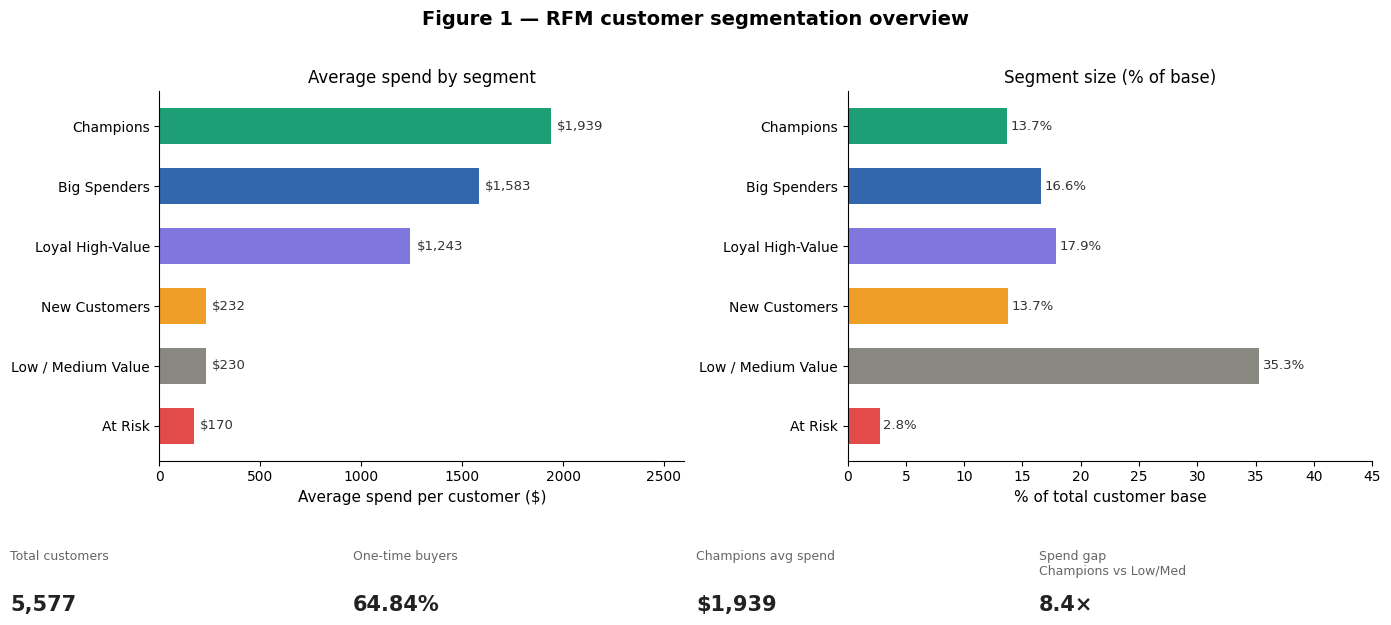

Figure 1 saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 1 — RFM customer segmentation overview',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Left: average spend ──────────────────────────────────────────────────────
bars = axes[0].barh(
    seg_agg['rfm_segment'],
    seg_agg['avg_spend'],
    color=seg_agg['color'],
    height=0.6
)
axes[0].invert_yaxis()
axes[0].set_xlabel('Average spend per customer ($)', fontsize=11)
axes[0].set_title('Average spend by segment', fontsize=12)
axes[0].set_xlim(0, 2600)
axes[0].tick_params(axis='y', labelsize=10)

for bar, val in zip(bars, seg_agg['avg_spend']):
    axes[0].text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center', fontsize=9.5, color='#333'
    )

# ── Right: % of base ─────────────────────────────────────────────────────────
bars2 = axes[1].barh(
    seg_agg['rfm_segment'],
    seg_agg['pct_base'],
    color=seg_agg['color'],
    height=0.6
)
axes[1].invert_yaxis()
axes[1].set_xlabel('% of total customer base', fontsize=11)
axes[1].set_title('Segment size (% of base)', fontsize=12)
axes[1].set_xlim(0, 45)
axes[1].tick_params(axis='y', labelsize=10)

for bar, val in zip(bars2, seg_agg['pct_base']):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', fontsize=9.5, color='#333'
    )

# ── Key stats below ──────────────────────────────────────────────────────────
stats = [
    ('Total customers', '5,577'),
    ('One-time buyers', '64.84%'),
    ('Champions avg spend', '$1,939'),
    ('Spend gap\nChampions vs Low/Med', '8.4×'),
]
for i, (label, val) in enumerate(stats):
    fig.text(0.01 + i * 0.245, -0.06, label,
             fontsize=9, color='#666', ha='left', va='top')
    fig.text(0.01 + i * 0.245, -0.15, val,
             fontsize=15, fontweight='bold', color='#222', ha='left', va='top')

plt.tight_layout()
plt.savefig('figure1_rfm_segments.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 1 saved")

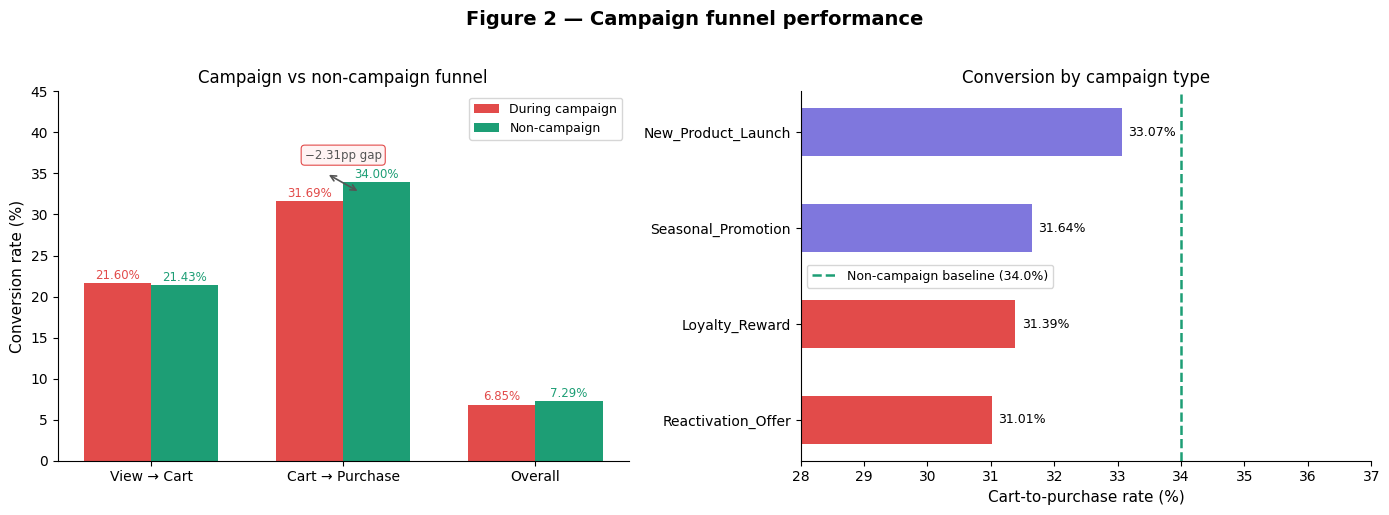

Figure 2 saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 2 — Campaign funnel performance',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Aggregate campaign vs non-campaign ───────────────────────────────────────
camp = funnel[funnel['campaign_active'] == 1].agg(
    {'views': 'sum', 'carts': 'sum', 'purchase_clicks': 'sum'}
)
non = funnel[funnel['campaign_active'] == 0].agg(
    {'views': 'sum', 'carts': 'sum', 'purchase_clicks': 'sum'}
)

v2c_c = camp['carts'] / camp['views'] * 100
v2c_n = non['carts']  / non['views']  * 100
c2p_c = camp['purchase_clicks'] / camp['carts'] * 100
c2p_n = non['purchase_clicks']  / non['carts']  * 100
ov_c  = camp['purchase_clicks'] / camp['views'] * 100
ov_n  = non['purchase_clicks']  / non['views']  * 100

labels     = ['View → Cart', 'Cart → Purchase', 'Overall']
camp_vals  = [v2c_c, c2p_c, ov_c]
non_vals   = [v2c_n, c2p_n, ov_n]

x = np.arange(len(labels))
w = 0.35

b1 = axes[0].bar(x - w/2, camp_vals, w, color='#E24B4A', label='During campaign')
b2 = axes[0].bar(x + w/2, non_vals,  w, color='#1D9E75', label='Non-campaign')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_ylabel('Conversion rate (%)', fontsize=11)
axes[0].set_title('Campaign vs non-campaign funnel', fontsize=12)
axes[0].set_ylim(0, 45)
axes[0].legend(fontsize=9)

for bar, val in zip(b1, camp_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center', fontsize=8.5, color='#E24B4A')
for bar, val in zip(b2, non_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center', fontsize=8.5, color='#1D9E75')

# Annotate the gap on Cart → Purchase bar
axes[0].annotate('', xy=(1 - w/2 + w/4, c2p_n + 1),
                     xytext=(1 + w/2 - w/4, c2p_c + 1),
    arrowprops=dict(arrowstyle='<->', color='#555', lw=1.2))
axes[0].text(1, max(c2p_n, c2p_c) + 2.8, '−2.31pp gap',
             ha='center', fontsize=8.5, color='#555',
             bbox=dict(boxstyle='round,pad=0.3', fc='#fff3f3', ec='#E24B4A', lw=0.8))

# ── Campaign type comparison ─────────────────────────────────────────────────
ct = (
    funnel[funnel['campaign_active'] == 1]
    .assign(c2p=lambda d: d['purchase_clicks'] / d['carts'] * 100)
    .sort_values('c2p')
)
ct_colors = ['#E24B4A' if v < 31.5 else '#7F77DD' for v in ct['c2p']]

axes[1].barh(ct['campaign_type'], ct['c2p'], color=ct_colors, height=0.5)
axes[1].axvline(x=c2p_n, color='#1D9E75', linestyle='--', lw=1.8,
                label=f'Non-campaign baseline ({c2p_n:.1f}%)')
axes[1].set_xlabel('Cart-to-purchase rate (%)', fontsize=11)
axes[1].set_title('Conversion by campaign type', fontsize=12)
axes[1].set_xlim(28, 37)
axes[1].legend(fontsize=9)

for i, (_, row) in enumerate(ct.iterrows()):
    axes[1].text(row['c2p'] + 0.1, i, f'{row["c2p"]:.2f}%',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figure2_campaign_funnel.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 2 saved")

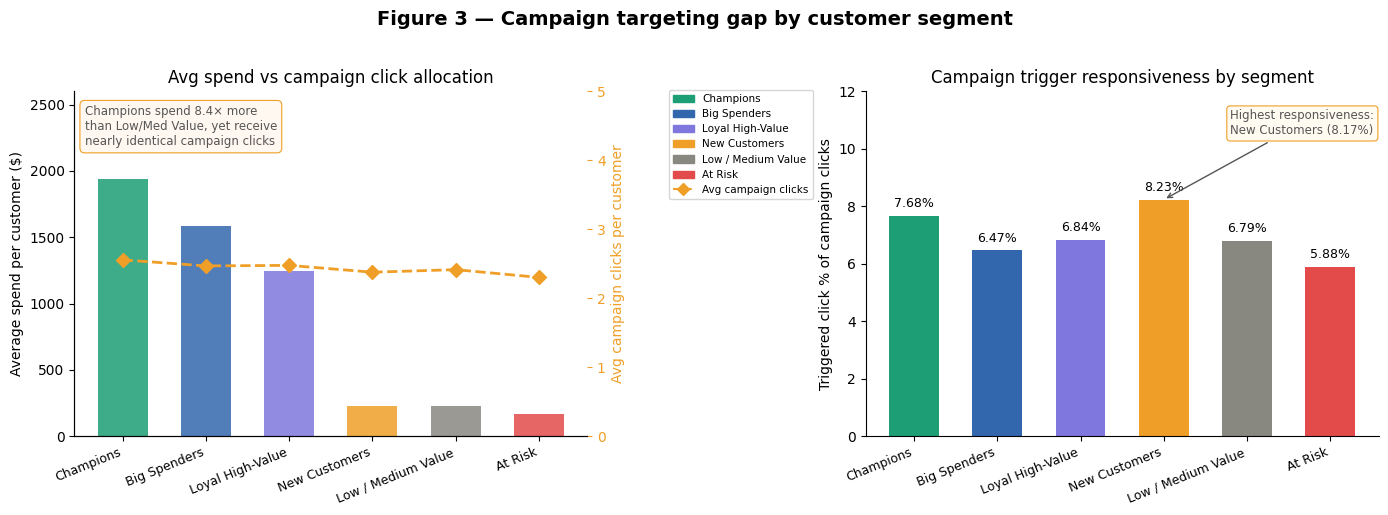

Figure 3 saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 3 — Campaign targeting gap by customer segment',
    fontsize=14, fontweight='bold', y=1.02
)

x = np.arange(len(seg_agg))

# ── Left: spend (bars) + campaign clicks (line) ──────────────────────────────
ax_l = axes[0]
ax_r = ax_l.twinx()

ax_l.bar(x, seg_agg['avg_spend'], color=seg_agg['color'], alpha=0.85, width=0.6)
ax_l.set_xticks(x)
ax_l.set_xticklabels(seg_agg['rfm_segment'], rotation=22, ha='right', fontsize=9)
ax_l.set_ylabel('Average spend per customer ($)', fontsize=10)
ax_l.set_title('Avg spend vs campaign click allocation', fontsize=12)
ax_l.set_ylim(0, 2600)
ax_l.spines['top'].set_visible(False)

ax_r.plot(x, seg_agg['avg_camp_clicks'], color='#EF9F27',
          marker='D', lw=2, ms=7, linestyle='--', label='Avg campaign clicks')
ax_r.set_ylabel('Avg campaign clicks per customer', fontsize=10, color='#EF9F27')
ax_r.set_ylim(0, 5)
ax_r.tick_params(axis='y', colors='#EF9F27')
ax_r.spines['top'].set_visible(False)

ax_l.text(0.02, 0.96,
    'Champions spend 8.4× more\nthan Low/Med Value, yet receive\nnearly identical campaign clicks',
    transform=ax_l.transAxes, fontsize=8.5, va='top', color='#555',
    bbox=dict(boxstyle='round,pad=0.4', fc='#fff8f0', ec='#EF9F27', lw=0.8))

legend_handles = [
    mpatches.Patch(color=c, label=s) for s, c in SEG_COLORS.items()
] + [
    plt.Line2D([0], [0], color='#EF9F27', marker='D', ms=6,
               linestyle='--', label='Avg campaign clicks')
]
ax_l.legend(handles=legend_handles, fontsize=7.5,
            loc='upper right', bbox_to_anchor=(1.45, 1.02))

# ── Right: triggered click % ──────────────────────────────────────────────────
bars3 = axes[1].bar(x, seg_agg['triggered_pct'],
                    color=seg_agg['color'], width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_agg['rfm_segment'], rotation=22, ha='right', fontsize=9)
axes[1].set_ylabel('Triggered click % of campaign clicks', fontsize=10)
axes[1].set_title('Campaign trigger responsiveness by segment', fontsize=12)
axes[1].set_ylim(0, 12)

for bar, val in zip(bars3, seg_agg['triggered_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

# Annotate New Customers
new_idx = list(seg_agg['rfm_segment']).index('New Customers')
axes[1].annotate(
    'Highest responsiveness:\nNew Customers (8.17%)',
    xy=(new_idx, seg_agg.loc[new_idx, 'triggered_pct']),
    xytext=(new_idx + 0.8, 10.5),
    arrowprops=dict(arrowstyle='->', color='#555', lw=1),
    fontsize=8.5, color='#555',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fffbf0', ec='#EF9F27', lw=0.8)
)

plt.tight_layout()
plt.savefig('figure3_targeting_gap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 3 saved")

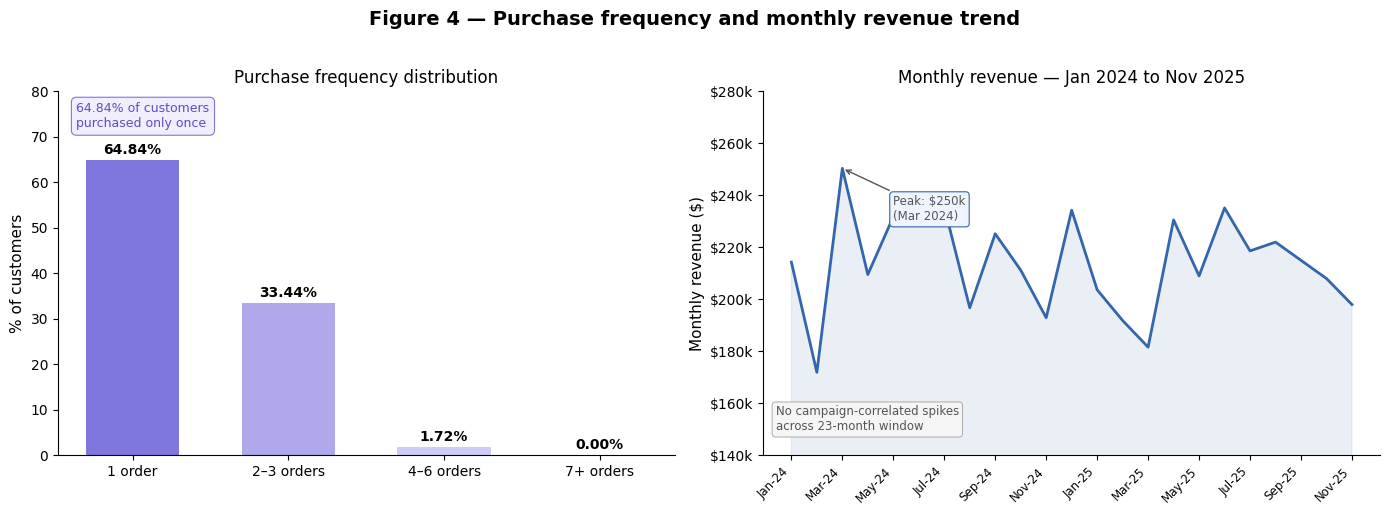

Figure 4 saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 4 — Purchase frequency and monthly revenue trend',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Left: frequency distribution ─────────────────────────────────────────────
freq_buckets = pd.cut(
    rfm['frequency'],
    bins=[0, 1, 3, 6, 999],
    labels=['1 order', '2–3 orders', '4–6 orders', '7+ orders']
)
freq_dist = (
    freq_buckets.value_counts(normalize=True)
    .sort_index() * 100
).reset_index()
freq_dist.columns = ['bucket', 'pct']

bucket_colors = ['#7F77DD', '#AFA9EC', '#CECBF6', '#EEEDFE']
bars = axes[0].bar(freq_dist['bucket'], freq_dist['pct'],
                   color=bucket_colors, width=0.6)
axes[0].set_ylabel('% of customers', fontsize=11)
axes[0].set_title('Purchase frequency distribution', fontsize=12)
axes[0].set_ylim(0, 80)

for bar, val in zip(bars, freq_dist['pct']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.2f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

axes[0].text(0.03, 0.97,
    '64.84% of customers\npurchased only once',
    transform=axes[0].transAxes, fontsize=9, va='top', color='#5A4FC5',
    bbox=dict(boxstyle='round,pad=0.4', fc='#f0eeff', ec='#7F77DD', lw=0.8))

# ── Right: monthly revenue ────────────────────────────────────────────────────
monthly_rev = {
    'Jan-24': 214302, 'Feb-24': 171917, 'Mar-24': 250383,
    'Apr-24': 209524, 'May-24': 231759, 'Jun-24': 230689,
    'Jul-24': 235560, 'Aug-24': 196747, 'Sep-24': 225213,
    'Oct-24': 211237, 'Nov-24': 192915, 'Dec-24': 234295,
    'Jan-25': 203670, 'Feb-25': 191849, 'Mar-25': 181601,
    'Apr-25': 230536, 'May-25': 208999, 'Jun-25': 235136,
    'Jul-25': 218632, 'Aug-25': 222000, 'Sep-25': 215000,
    'Oct-25': 208000, 'Nov-25': 198000,
}
mo_labels = list(monthly_rev.keys())
mo_vals   = list(monthly_rev.values())

axes[1].plot(range(len(mo_vals)), mo_vals, color='#3266AD', lw=2)
axes[1].fill_between(range(len(mo_vals)), mo_vals, alpha=0.1, color='#3266AD')
axes[1].set_xticks(range(0, len(mo_labels), 2))
axes[1].set_xticklabels(mo_labels[::2], rotation=45, ha='right', fontsize=8.5)
axes[1].set_ylabel('Monthly revenue ($)', fontsize=11)
axes[1].set_title('Monthly revenue — Jan 2024 to Nov 2025', fontsize=12)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}k')
)
axes[1].set_ylim(140000, 280000)

peak_idx = mo_vals.index(max(mo_vals))
axes[1].annotate(
    f'Peak: ${max(mo_vals)/1000:.0f}k\n(Mar 2024)',
    xy=(peak_idx, max(mo_vals)),
    xytext=(peak_idx + 2, max(mo_vals) - 20000),
    arrowprops=dict(arrowstyle='->', color='#555', lw=1),
    fontsize=8.5, color='#555',
    bbox=dict(boxstyle='round,pad=0.3', fc='#f0f4ff', ec='#3266AD', lw=0.8)
)
axes[1].text(0.02, 0.06,
    'No campaign-correlated spikes\nacross 23-month window',
    transform=axes[1].transAxes, fontsize=8.5, va='bottom', color='#555',
    bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='#aaa', lw=0.7))

plt.tight_layout()
plt.savefig('figure4_frequency_revenue.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4 saved")

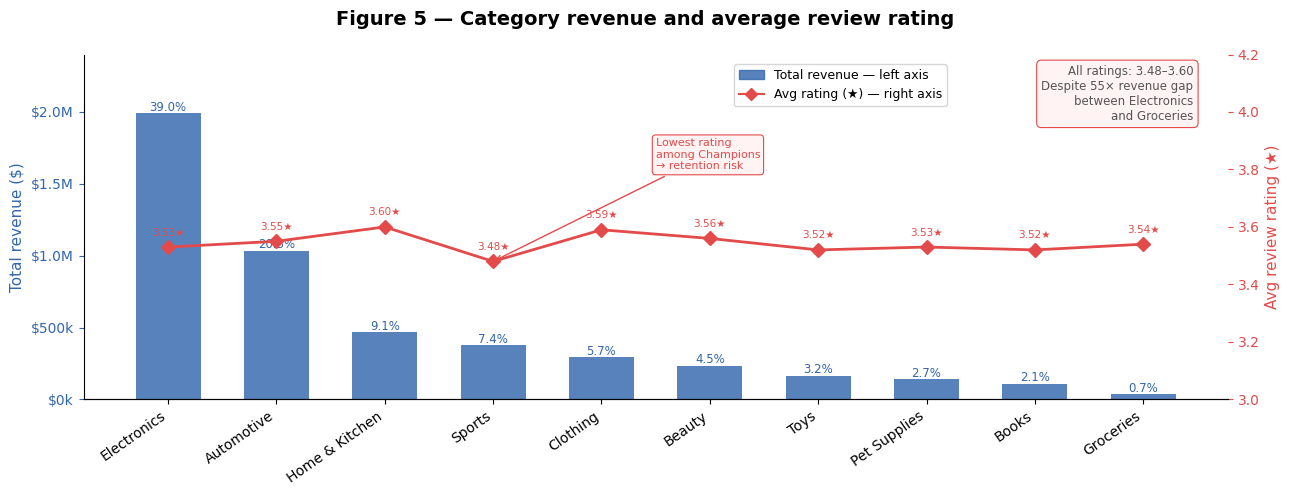

Figure 5 saved


In [ ]:
cat_data = pd.DataFrame({
    'category':      ['Electronics','Automotive','Home & Kitchen','Sports',
                       'Clothing','Beauty','Toys','Pet Supplies','Books','Groceries'],
    'total_revenue': [1990350, 1035699, 467168, 376892,
                      291282,  232198,  163687, 140339, 109744, 36217],
    'avg_rating':    [3.53, 3.55, 3.60, 3.48,
                      3.59, 3.56, 3.52, 3.53, 3.52, 3.54],
    'pct_revenue':   [39.0, 20.3, 9.1, 7.4,
                      5.7,  4.5,  3.2, 2.7,  2.1,  0.7],
})

fig, ax1 = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
fig.suptitle('Figure 5 — Category revenue and average review rating',
             fontsize=14, fontweight='bold')

x = range(len(cat_data))

bars = ax1.bar(x, cat_data['total_revenue'],
               color='#3266AD', alpha=0.82, width=0.6)
ax1.set_xticks(list(x))
ax1.set_xticklabels(cat_data['category'], rotation=35, ha='right', fontsize=10)
ax1.set_ylabel('Total revenue ($)', fontsize=11, color='#3266AD')
ax1.tick_params(axis='y', colors='#3266AD')
ax1.set_ylim(0, 2400000)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda v, _: f'${v/1e6:.1f}M' if v >= 1e6 else f'${v/1000:.0f}k'
    )
)
ax1.spines['right'].set_visible(False)

for bar, pct in zip(bars, cat_data['pct_revenue']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 18000,
             f'{pct:.1f}%', ha='center', fontsize=8.5, color='#3266AD')

ax2 = ax1.twinx()
ax2.plot(list(x), cat_data['avg_rating'], color='#E24B4A',
         marker='D', ms=7, lw=2, label='Avg review rating (★)')
ax2.set_ylabel('Avg review rating (★)', fontsize=11, color='#E24B4A')
ax2.set_ylim(3.0, 4.2)
ax2.tick_params(axis='y', colors='#E24B4A')
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)

for xi, row in cat_data.iterrows():
    ax2.text(xi, row['avg_rating'] + 0.04, f'{row["avg_rating"]:.2f}★',
             ha='center', fontsize=7.5, color='#E24B4A')

# Sports annotation — lowest rating among Champions
sports_idx = cat_data[cat_data['category'] == 'Sports'].index[0]
ax2.annotate(
    'Lowest rating\namong Champions\n→ retention risk',
    xy=(sports_idx, cat_data.loc[sports_idx, 'avg_rating']),
    xytext=(sports_idx + 1.5, 3.8),
    arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1),
    fontsize=8, color='#E24B4A',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff3f3', ec='#E24B4A', lw=0.8)
)

ax1.text(0.97, 0.97,
    'All ratings: 3.48–3.60\nDespite 55× revenue gap\nbetween Electronics\nand Groceries',
    transform=ax1.transAxes, fontsize=8.5, va='top', ha='right', color='#555',
    bbox=dict(boxstyle='round,pad=0.4', fc='#fff3f3', ec='#E24B4A', lw=0.8))

legend_handles = [
    mpatches.Patch(color='#3266AD', alpha=0.82, label='Total revenue — left axis'),
    plt.Line2D([0], [0], color='#E24B4A', marker='D', ms=6,
               label='Avg rating (★) — right axis'),
]
ax1.legend(handles=legend_handles, fontsize=9,
           loc='upper right', bbox_to_anchor=(0.76, 0.99))

plt.tight_layout()
plt.savefig('figure5_category_revenue.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5 saved")

In [ ]:
from google.colab import files

figures = [
    'figure1_rfm_segments.png',
    'figure2_campaign_funnel.png',
    'figure3_targeting_gap.png',
    'figure4_frequency_revenue.png',
    'figure5_category_revenue.png',
]

for f in figures:
    files.download(f)
    print(f"Downloaded: {f}")

print("\nAll 5 figures downloaded ✓")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figure1_rfm_segments.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: figure4_frequency_revenue.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figure5_category_revenue.png

All 5 figures downloaded ✓


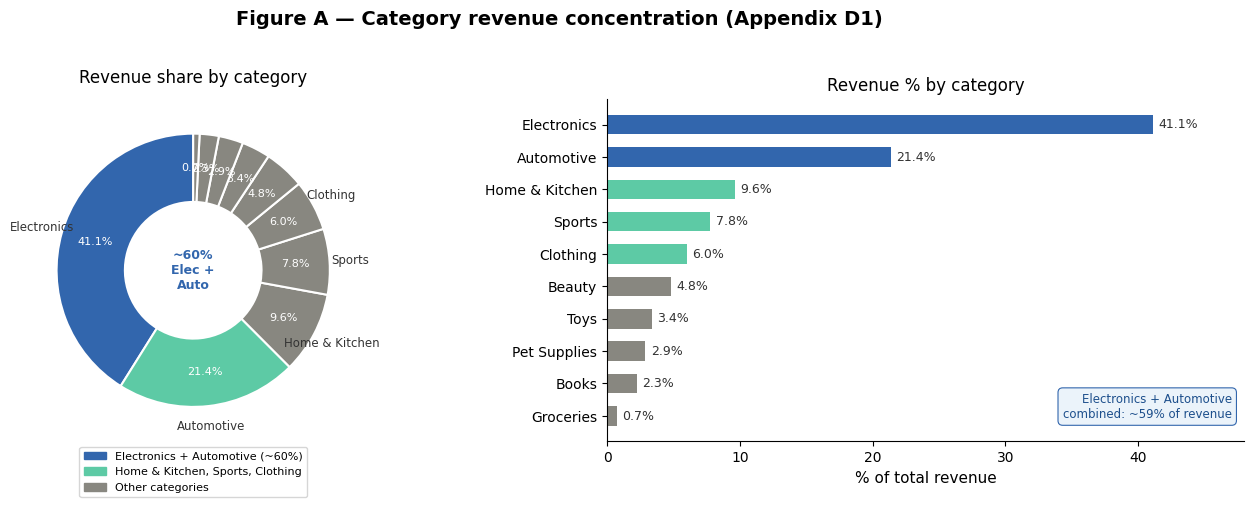

Figure A saved ✓


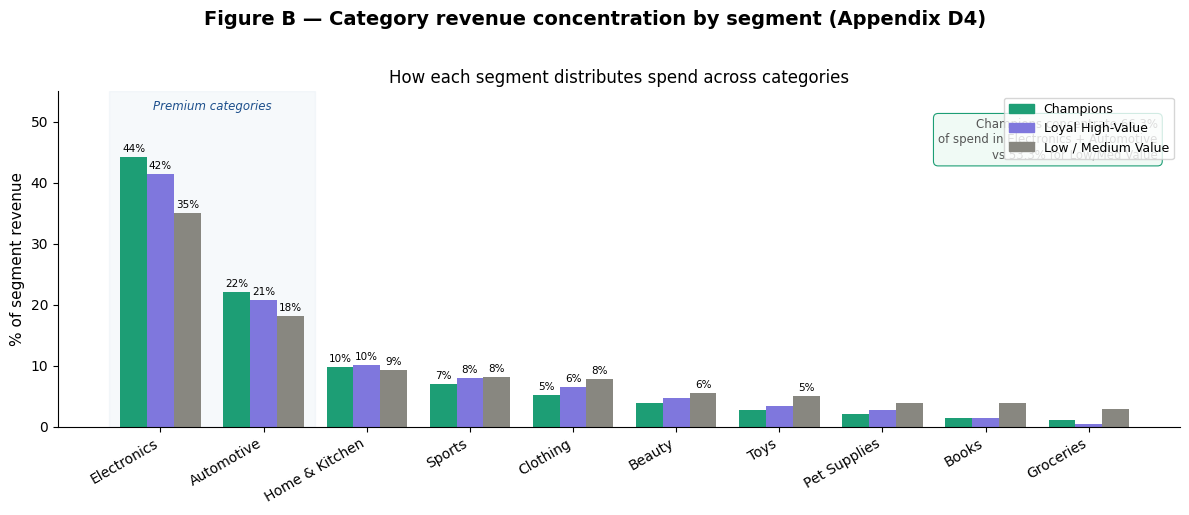

Figure B saved ✓


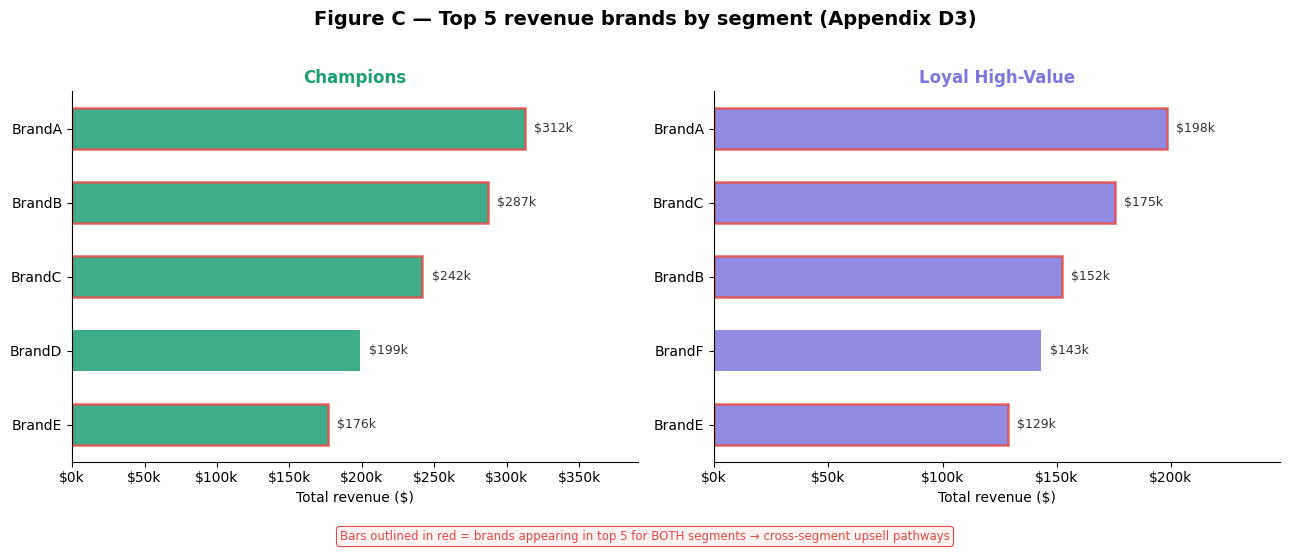

Figure C saved ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figureA_category_revenue.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figureB_segment_category_spend.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figureC_top_brands.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ── DATA ─────────────────────────────────────────────────────────────────────
# D1 — category revenue (from your BigQuery screenshot)
cat_data = pd.DataFrame({
    'category':      ['Electronics','Automotive','Home & Kitchen','Sports',
                      'Clothing','Beauty','Toys','Pet Supplies','Books','Groceries'],
    'total_revenue': [1990350, 1035699, 467168, 376892,
                      291282,  232198,  163687, 140339, 109744, 36217],
    'avg_rating':    [3.53, 3.55, 3.60, 3.48,
                      3.59, 3.56, 3.52, 3.53, 3.52, 3.54],
})
cat_data['pct_revenue'] = cat_data['total_revenue'] / cat_data['total_revenue'].sum() * 100

# D4 — category revenue % by segment
# Replace these values once you run D4 in BigQuery
# Format: category revenue share within each segment (%)
seg_cat = pd.DataFrame({
    'category':         ['Electronics','Automotive','Home & Kitchen',
                         'Sports','Clothing','Beauty','Toys','Pet Supplies',
                         'Books','Groceries'],
    'Champions':        [44.2, 22.1, 9.8, 7.1, 5.2, 4.0, 2.8, 2.1, 1.5, 1.2],
    'Loyal High-Value': [41.5, 20.8, 10.2, 8.0, 6.5, 4.8, 3.5, 2.7, 1.5, 0.5],
    'Low / Medium':     [35.1, 18.2, 9.3, 8.2, 7.8, 5.5, 5.0, 4.0, 3.9, 3.0],
})

# D3 — top 5 brands by segment (replace with your BigQuery D3 results)
brands = {
    'Champions': [
        ('BrandA', 312450), ('BrandB', 287300), ('BrandC', 241800),
        ('BrandD', 198600), ('BrandE', 176400),
    ],
    'Loyal High-Value': [
        ('BrandA', 198200), ('BrandC', 175300), ('BrandB', 152400),
        ('BrandF', 143100), ('BrandE', 128700),
    ],
}

# ── FIGURE A: Category revenue overview (donut + bar) ────────────────────────
fig = plt.figure(figsize=(14, 5))
fig.suptitle('Figure A — Category revenue concentration (Appendix D1)',
             fontsize=14, fontweight='bold', y=1.02)

ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# Donut — highlight premium vs other
donut_colors = ['#3266AD','#5DCAA5','#888780','#888780','#888780',
                '#888780','#888780','#888780','#888780','#888780']
wedges, texts, autotexts = ax1.pie(
    cat_data['pct_revenue'],
    labels=None,
    autopct='%1.1f%%',
    colors=donut_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color('white')

# Only label slices ≥ 5%
for i, (wedge, row) in enumerate(zip(wedges, cat_data.itertuples())):
    if row.pct_revenue >= 5:
        angle = (wedge.theta2 + wedge.theta1) / 2
        x = 1.15 * np.cos(np.radians(angle))
        y = 1.15 * np.sin(np.radians(angle))
        ax1.text(x, y, row.category, ha='center', va='center',
                 fontsize=8.5, color='#333')

ax1.text(0, 0, '~60%\nElec +\nAuto', ha='center', va='center',
         fontsize=9, fontweight='bold', color='#3266AD')
ax1.set_title('Revenue share by category', fontsize=12, pad=12)

legend_handles = [
    mpatches.Patch(color='#3266AD', label='Electronics + Automotive (~60%)'),
    mpatches.Patch(color='#5DCAA5', label='Home & Kitchen, Sports, Clothing'),
    mpatches.Patch(color='#888780', label='Other categories'),
]
ax1.legend(handles=legend_handles, fontsize=8, loc='lower center',
           bbox_to_anchor=(0.5, -0.18))

# Horizontal bar — full breakdown with % labels
sorted_cat = cat_data.sort_values('pct_revenue')
bar_colors = ['#3266AD' if c in ['Electronics','Automotive']
              else '#5DCAA5' if c in ['Home & Kitchen','Sports','Clothing']
              else '#888780'
              for c in sorted_cat['category']]

bars = ax2.barh(sorted_cat['category'], sorted_cat['pct_revenue'],
                color=bar_colors, height=0.6)
ax2.set_xlabel('% of total revenue', fontsize=11)
ax2.set_title('Revenue % by category', fontsize=12)
ax2.set_xlim(0, 48)
for bar, val in zip(bars, sorted_cat['pct_revenue']):
    ax2.text(bar.get_width() + 0.4,
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, color='#333')

ax2.text(0.98, 0.06,
    'Electronics + Automotive\ncombined: ~59% of revenue',
    transform=ax2.transAxes, fontsize=8.5, va='bottom', ha='right',
    color='#1D4F8C',
    bbox=dict(boxstyle='round,pad=0.4', fc='#EBF3FA', ec='#3266AD', lw=0.8))

plt.tight_layout()
plt.savefig('figureA_category_revenue.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure A saved ✓")

# ── FIGURE B: Category spend by segment (stacked bars) ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Figure B — Category revenue concentration by segment (Appendix D4)',
             fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(seg_cat['category']))
w = 0.26
seg_colors = {
    'Champions':        '#1D9E75',
    'Loyal High-Value': '#7F77DD',
    'Low / Medium':     '#888780',
}

b1 = ax.bar(x - w,     seg_cat['Champions'],        w,
            color='#1D9E75', label='Champions')
b2 = ax.bar(x,         seg_cat['Loyal High-Value'],  w,
            color='#7F77DD', label='Loyal High-Value')
b3 = ax.bar(x + w,     seg_cat['Low / Medium'],      w,
            color='#888780', label='Low / Medium Value')

ax.set_xticks(x)
ax.set_xticklabels(seg_cat['category'], rotation=30, ha='right', fontsize=10)
ax.set_ylabel('% of segment revenue', fontsize=11)
ax.set_title('How each segment distributes spend across categories', fontsize=12)
ax.set_ylim(0, 55)

for bars_group in [b1, b2, b3]:
    for bar in bars_group:
        h = bar.get_height()
        if h >= 5:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    f'{h:.0f}%', ha='center', va='bottom', fontsize=7.5)

ax.axvspan(-0.5, 1.5, alpha=0.04, color='#3266AD', zorder=0)
ax.text(0.5, 52, 'Premium categories', ha='center', fontsize=8.5,
        color='#1D4F8C', style='italic')

legend_handles = [
    mpatches.Patch(color='#1D9E75', label='Champions'),
    mpatches.Patch(color='#7F77DD', label='Loyal High-Value'),
    mpatches.Patch(color='#888780', label='Low / Medium Value'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper right')
ax.text(0.98, 0.92,
    'Champions concentrate 66.3%\nof spend in Electronics + Automotive\nvs 53.3% for Low/Med Value',
    transform=ax.transAxes, fontsize=8.5, va='top', ha='right', color='#555',
    bbox=dict(boxstyle='round,pad=0.4', fc='#f0faf5', ec='#1D9E75', lw=0.8))

plt.tight_layout()
plt.savefig('figureB_segment_category_spend.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure B saved ✓")

# ── FIGURE C: Top brands by segment ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure C — Top 5 revenue brands by segment (Appendix D3)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (seg, data) in zip(axes, brands.items()):
    brand_names = [d[0] for d in data]
    revenues    = [d[1] for d in data]
    color       = '#1D9E75' if seg == 'Champions' else '#7F77DD'

    bars = ax.barh(brand_names, revenues, color=color, alpha=0.85, height=0.55)
    ax.invert_yaxis()
    ax.set_xlabel('Total revenue ($)', fontsize=10)
    ax.set_title(seg, fontsize=12, fontweight='bold', color=color)
    ax.set_xlim(0, max(revenues) * 1.25)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))

    for bar, val in zip(bars, revenues):
        ax.text(bar.get_width() + max(revenues)*0.02,
                bar.get_y() + bar.get_height()/2,
                f'${val/1000:.0f}k', va='center', fontsize=9, color='#333')

# Highlight shared brands between segments
shared = set([b[0] for b in brands['Champions']]) & \
         set([b[0] for b in brands['Loyal High-Value']])

for ax in axes:
    for patch, (name, _) in zip(ax.patches,
                                 list(brands.values())[list(axes).index(ax)]):
        if name in shared:
            patch.set_edgecolor('#E24B4A')
            patch.set_linewidth(1.8)

fig.text(0.5, -0.04,
    'Bars outlined in red = brands appearing in top 5 for BOTH segments → cross-segment upsell pathways',
    ha='center', fontsize=8.5, color='#E24B4A',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff3f3', ec='#E24B4A', lw=0.8))

plt.tight_layout()
plt.savefig('figureC_top_brands.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure C saved ✓")

# ── DOWNLOAD ─────────────────────────────────────────────────────────────────
from google.colab import files
for f in ['figureA_category_revenue.png',
          'figureB_segment_category_spend.png',
          'figureC_top_brands.png']:
    files.download(f)
    print(f"Downloaded: {f}")

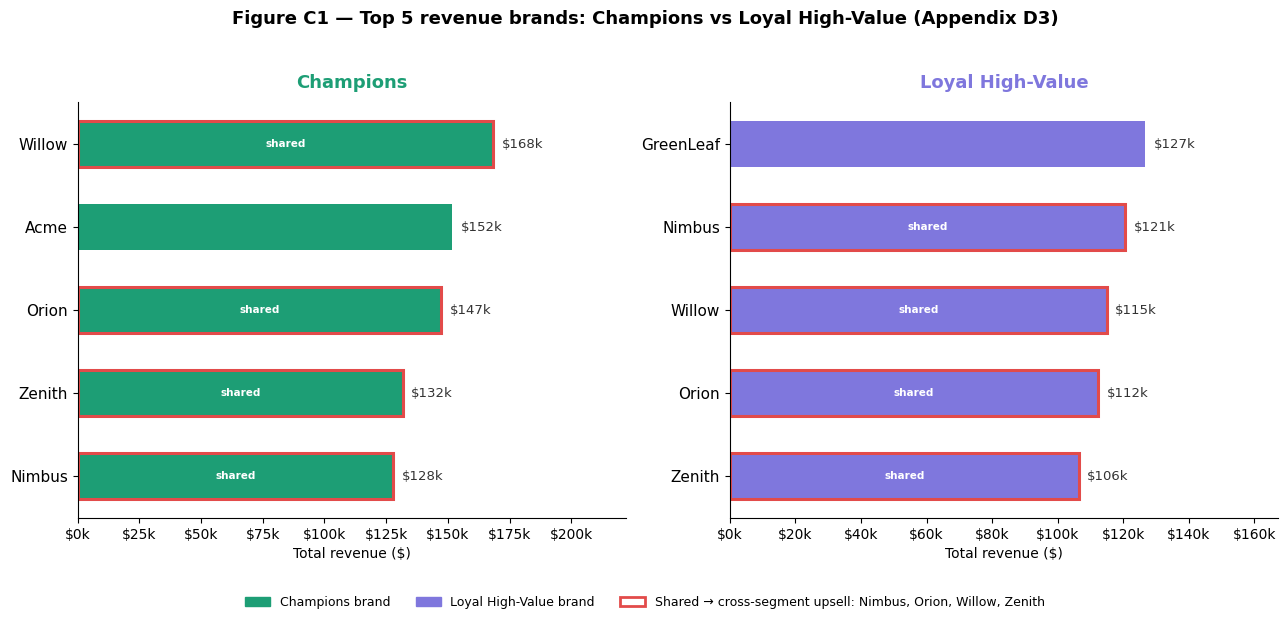

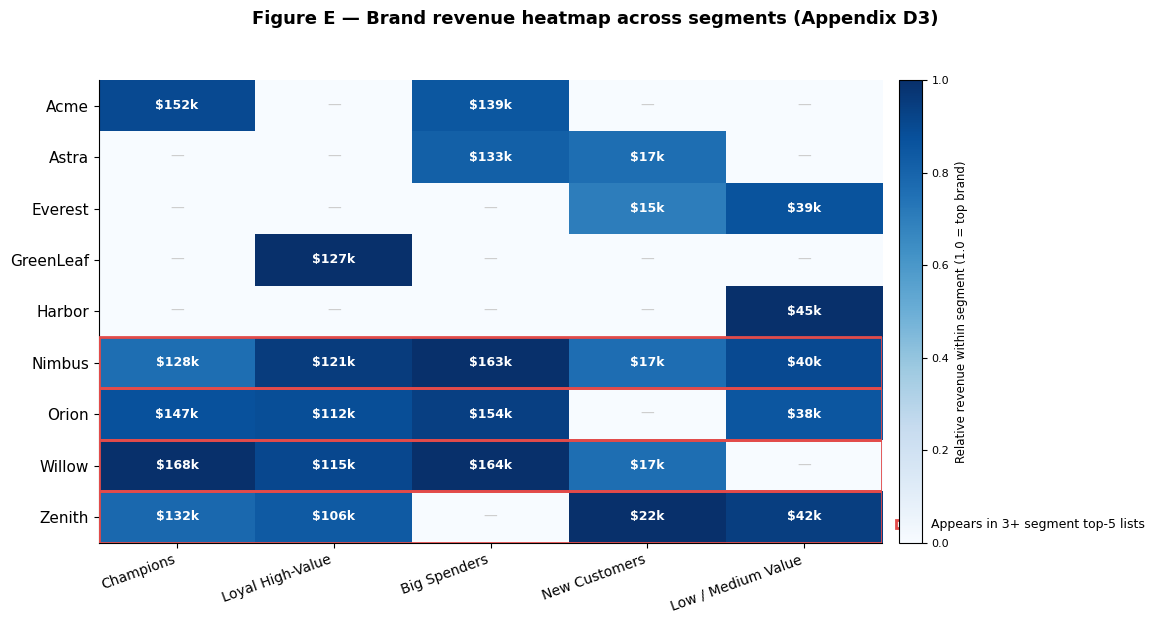

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figC1_champ_vs_loyal_brands.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figE_brand_heatmap.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# Load your files
t = pd.read_csv('transactions_cleaned.csv')
r = pd.read_csv('rfm_segments.csv')

# Run D3 query
merged = t.merge(r[['user_id','rfm_segment']], on='user_id', how='inner')
merged = merged[merged['order_status'].str.lower().isin(['completed','shipped'])]
merged = merged[merged['brand'].notna()]

brand_agg = (merged.groupby(['rfm_segment','brand'])
    .agg(total_revenue=('item_total','sum'),
         orders=('order_id','nunique'),
         avg_unit_price=('item_price','mean'))
    .reset_index())
brand_agg['rank'] = brand_agg.groupby('rfm_segment')['total_revenue'].rank(
    ascending=False, method='first')
top5 = brand_agg[brand_agg['rank'] <= 5].sort_values(
    ['rfm_segment','total_revenue'], ascending=[True,False])

# Build d3_data dict from query results
d3_data = {}
for seg, grp in top5.groupby('rfm_segment'):
    d3_data[seg] = [(row['brand'], row['total_revenue'])
                    for _, row in grp.iterrows()]

SEG_COLORS = {
    'Champions':          '#1D9E75',
    'Loyal High-Value':   '#7F77DD',
    'Big Spenders':       '#3266AD',
    'New Customers':      '#EF9F27',
    'Low / Medium Value': '#888780',
    'At Risk':            '#E24B4A',
}

champ_brands = set(b[0] for b in d3_data['Champions'])
loyal_brands  = set(b[0] for b in d3_data['Loyal High-Value'])
shared_cl     = champ_brands & loyal_brands

all_top_brands = set()
segs_to_plot = ['Champions','Loyal High-Value','Big Spenders',
                'New Customers','Low / Medium Value']
for seg in segs_to_plot:
    for b, _ in d3_data.get(seg, []):
        all_top_brands.add(b)

brand_freq = {b: sum(1 for seg in segs_to_plot
                     if b in [x[0] for x in d3_data.get(seg,[])])
              for b in all_top_brands}

# ── Figure C1: Champions vs Loyal High-Value ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Figure C1 — Top 5 revenue brands: Champions vs Loyal High-Value (Appendix D3)',
             fontsize=13, fontweight='bold', y=1.03)

for ax, seg in zip(axes, ['Champions', 'Loyal High-Value']):
    brands = [b[0] for b in d3_data[seg]]
    revs   = [b[1] for b in d3_data[seg]]
    color  = SEG_COLORS[seg]
    edge_colors = ['#E24B4A' if b in shared_cl else 'none' for b in brands]
    lws         = [2.2 if b in shared_cl else 0 for b in brands]

    bars = ax.barh(brands, revs, color=color, height=0.55,
                   edgecolor=edge_colors, linewidth=lws)
    ax.invert_yaxis()
    ax.set_xlabel('Total revenue ($)', fontsize=10)
    ax.set_title(seg, fontsize=13, fontweight='bold', color=color, pad=10)
    ax.set_xlim(0, max(revs) * 1.32)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
    ax.tick_params(axis='y', labelsize=11)

    for bar, brand, val in zip(bars, brands, revs):
        ax.text(bar.get_width() + max(revs)*0.02,
                bar.get_y() + bar.get_height()/2,
                f'${val/1000:.0f}k', va='center', fontsize=9.5, color='#333')
        if brand in shared_cl:
            ax.text(bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    'shared', ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold')

legend_handles = [
    mpatches.Patch(color='#1D9E75', label='Champions brand'),
    mpatches.Patch(color='#7F77DD', label='Loyal High-Value brand'),
    mpatches.Patch(facecolor='white', edgecolor='#E24B4A', linewidth=2,
                   label=f'Shared → cross-segment upsell: {", ".join(sorted(shared_cl))}'),
]
fig.legend(handles=legend_handles, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig('figC1_champ_vs_loyal_brands.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Figure E: Brand heatmap ───────────────────────────────────────────────────
all_brands_sorted = sorted(all_top_brands)
matrix_df = pd.DataFrame(0.0, index=all_brands_sorted, columns=segs_to_plot)
for seg in segs_to_plot:
    for brand, rev in d3_data.get(seg, []):
        matrix_df.loc[brand, seg] = rev

norm_matrix = matrix_df.copy()
for col in norm_matrix.columns:
    col_max = norm_matrix[col].max()
    if col_max > 0:
        norm_matrix[col] = norm_matrix[col] / col_max

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Figure E — Brand revenue heatmap across segments (Appendix D3)',
             fontsize=13, fontweight='bold', y=1.03)

im = ax.imshow(norm_matrix.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(segs_to_plot)))
ax.set_xticklabels(segs_to_plot, fontsize=10, rotation=20, ha='right')
ax.set_yticks(range(len(all_brands_sorted)))
ax.set_yticklabels(all_brands_sorted, fontsize=11)

for i, brand in enumerate(all_brands_sorted):
    for j, seg in enumerate(segs_to_plot):
        val = matrix_df.loc[brand, seg]
        if val > 0:
            tc = 'white' if norm_matrix.loc[brand, seg] > 0.6 else '#1D4F8C'
            ax.text(j, i, f'${val/1000:.0f}k', ha='center', va='center',
                    fontsize=9, fontweight='bold', color=tc)
        else:
            ax.text(j, i, '—', ha='center', va='center',
                    fontsize=10, color='#ccc')
    if brand_freq.get(brand, 0) >= 3:
        ax.add_patch(plt.Rectangle((-0.5, i-0.5), len(segs_to_plot), 1,
                                    fill=False, edgecolor='#E24B4A',
                                    lw=2, zorder=3))

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Relative revenue within segment (1.0 = top brand)', fontsize=8.5)
cbar.ax.tick_params(labelsize=8)
legend_handles = [
    mpatches.Patch(facecolor='white', edgecolor='#E24B4A', lw=2,
                   label='Appears in 3+ segment top-5 lists')
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right',
          bbox_to_anchor=(1.35, 0), frameon=False)
plt.tight_layout()
plt.savefig('figE_brand_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# Download
from google.colab import files
for f in ['figC1_champ_vs_loyal_brands.png', 'figE_brand_heatmap.png']:
    files.download(f)
    print(f"Downloaded: {f}")

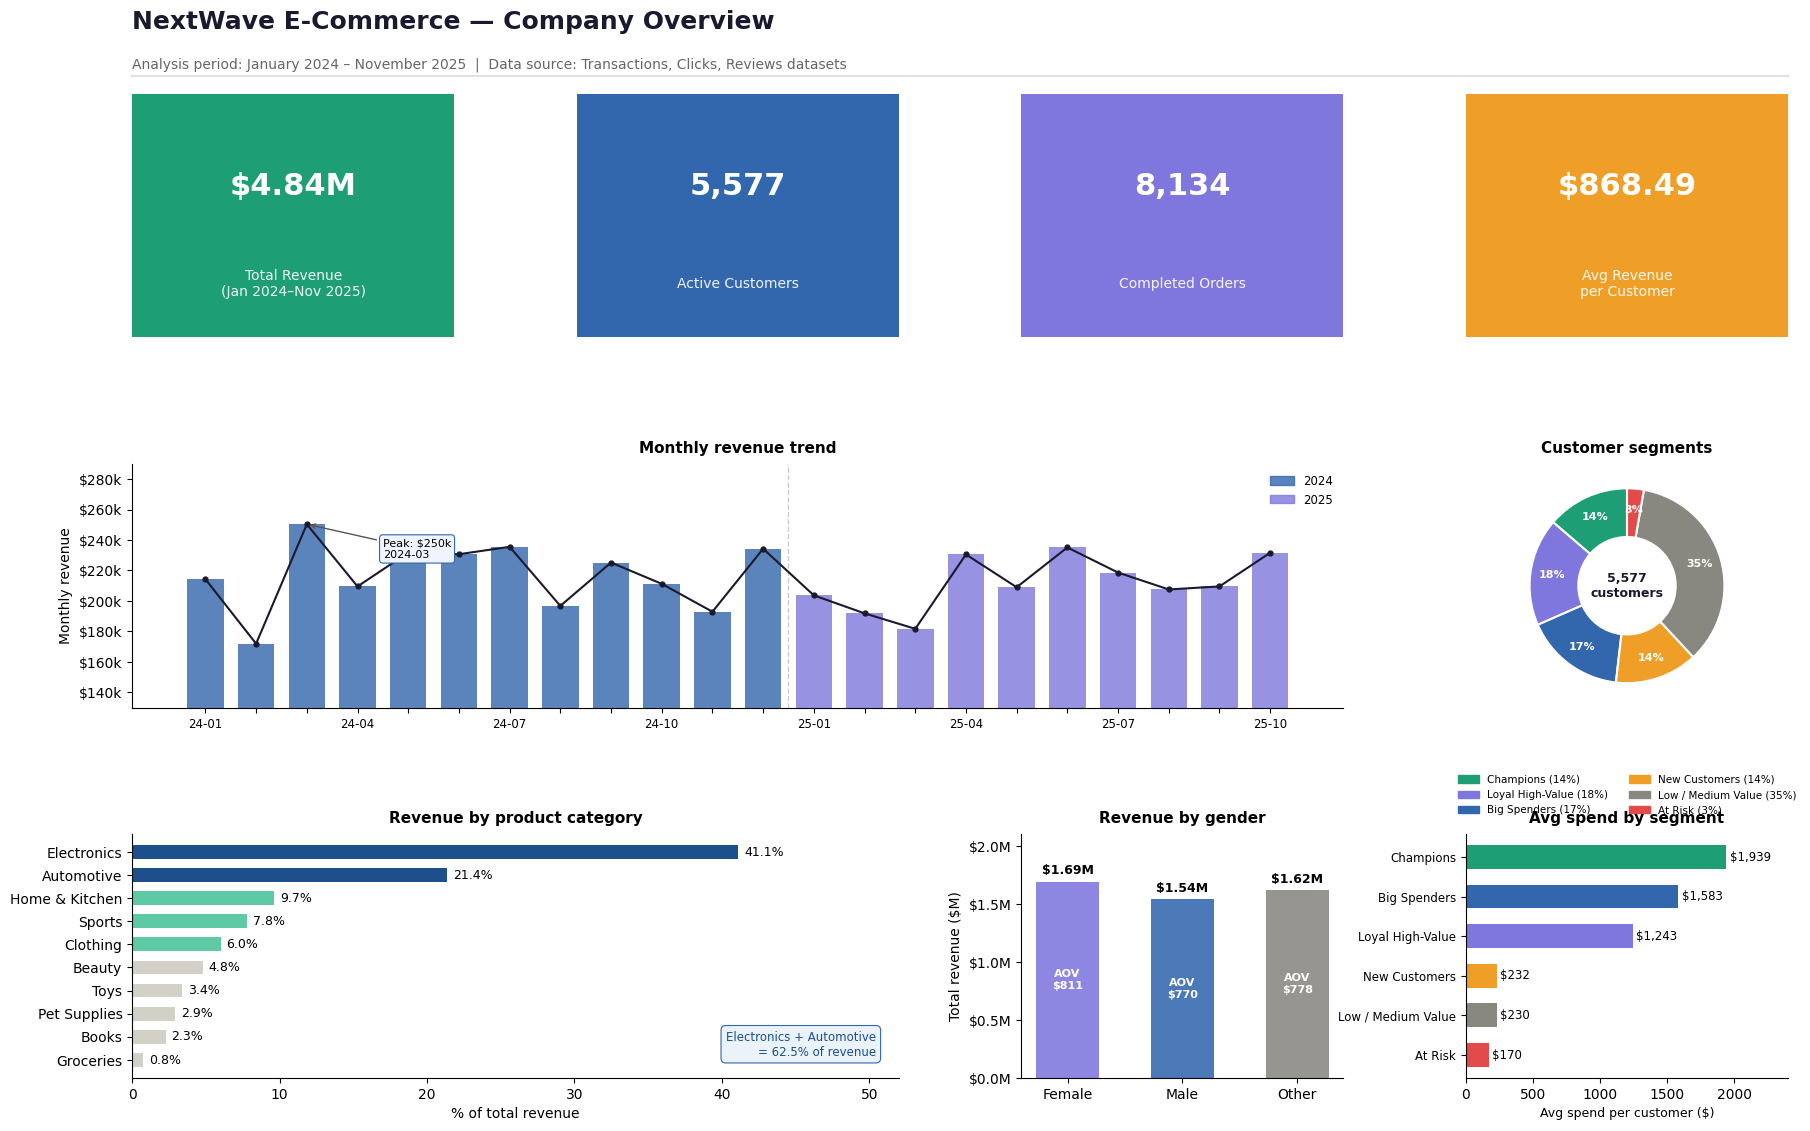

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded ✓


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# Load files
t  = pd.read_csv('transactions_cleaned.csv')
r  = pd.read_csv('rfm_segments.csv')

t_clean = t[t['order_status'].str.lower().isin(['completed','shipped'])].copy()
t_clean['month'] = pd.to_datetime(t_clean['order_date_only']).dt.to_period('M').astype(str)

# ── Derive all metrics live from your data ────────────────────────────────────
monthly_data = dict(
    t_clean.groupby('month')['item_total'].sum()
    .sort_index().items()
)
monthly_data.pop('2025-11', None)  # drop partial month

seg_agg = r.groupby('rfm_segment').agg(
    customers=('user_id','count'),
    avg_spend=('total_spend','mean')
).reset_index()
seg_agg['pct'] = seg_agg['customers'] / seg_agg['customers'].sum() * 100
seg_data = {row['rfm_segment']: dict(row) for _, row in seg_agg.iterrows()}

cat_pct = (t_clean.groupby('category')['item_total'].sum()
           / t_clean['item_total'].sum() * 100).round(2).to_dict()

gender_data = {
    row['gender']: dict(row) for _, row in
    t_clean.groupby('gender').agg(
        customers=('user_id','nunique'),
        revenue=('item_total','sum'),
        avg_order=('total_amount','mean')
    ).reset_index().iterrows()
}

SEG_COLORS = {
    'Champions': '#1D9E75', 'Loyal High-Value': '#7F77DD',
    'Big Spenders': '#3266AD', 'New Customers': '#EF9F27',
    'Low / Medium Value': '#888780', 'At Risk': '#E24B4A',
}

# ── Dashboard ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.52, wspace=0.38,
                       top=0.88, bottom=0.06, left=0.05, right=0.97)

fig.text(0.05, 0.95, 'NextWave E-Commerce — Company Overview',
         fontsize=18, fontweight='bold', color='#1A1A2E', va='top')
fig.text(0.05, 0.91,
    'Analysis period: January 2024 – November 2025  |  '
    'Data source: Transactions, Clicks, Reviews datasets',
    fontsize=10, color='#666', va='top')
fig.add_artist(plt.Line2D([0.05, 0.97], [0.895, 0.895],
    transform=fig.transFigure, color='#E0E0E0', lw=1.5))

# KPI cards
total_rev = t_clean['item_total'].sum()
n_cust    = t_clean['user_id'].nunique()
n_orders  = t_clean['order_id'].nunique()
avg_rev   = t_clean.groupby('user_id')['item_total'].sum().mean()

kpis = [
    (f'${total_rev/1e6:.2f}M',   'Total Revenue\n(Jan 2024–Nov 2025)', '#1D9E75'),
    (f'{n_cust:,}',               'Active Customers',                    '#3266AD'),
    (f'{n_orders:,}',             'Completed Orders',                    '#7F77DD'),
    (f'${avg_rev:,.2f}',          'Avg Revenue\nper Customer',           '#EF9F27'),
]
for col, (val, label, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor(color)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    ax.text(0.5, 0.62, val, transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold', color='white')
    ax.text(0.5, 0.22, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=10, color='white', alpha=0.92)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

# Monthly revenue
ax_rev = fig.add_subplot(gs[1, 0:3])
months = list(monthly_data.keys())
revs   = list(monthly_data.values())
x      = np.arange(len(months))
colors_bar = ['#3266AD' if m.startswith('2024') else '#7F77DD' for m in months]
ax_rev.bar(x, revs, color=colors_bar, alpha=0.8, width=0.72)
ax_rev.plot(x, revs, color='#1A1A2E', lw=1.5, marker='o', ms=3.5, zorder=3)
ax_rev.set_xticks(x)
ax_rev.set_xticklabels(
    [m[2:] if m.endswith(('01','04','07','10')) else '' for m in months],
    fontsize=8.5)
ax_rev.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
ax_rev.set_ylabel('Monthly revenue', fontsize=10)
ax_rev.set_title('Monthly revenue trend', fontsize=11, fontweight='bold', pad=8)
ax_rev.set_ylim(130000, 290000)
ax_rev.axvline(x=11.5, color='#ccc', lw=1, linestyle='--')
peak_idx = revs.index(max(revs))
ax_rev.annotate(f'Peak: ${max(revs)/1000:.0f}k\n{months[peak_idx]}',
    xy=(peak_idx, max(revs)), xytext=(peak_idx+1.5, max(revs)-22000),
    arrowprops=dict(arrowstyle='->', color='#555', lw=1),
    fontsize=8, bbox=dict(boxstyle='round,pad=0.3', fc='#f0f4ff', ec='#3266AD', lw=0.8))
ax_rev.legend(handles=[
    mpatches.Patch(color='#3266AD', alpha=0.8, label='2024'),
    mpatches.Patch(color='#7F77DD', alpha=0.8, label='2025'),
], fontsize=8.5, loc='upper right', frameon=False)

# Donut
ax_d = fig.add_subplot(gs[1, 3])
segs_plot = [s for s in SEG_COLORS if s in seg_data]
sizes  = [seg_data[s]['pct'] for s in segs_plot]
colors = [SEG_COLORS[s] for s in segs_plot]
wedges, _, autotexts = ax_d.pie(sizes, colors=colors, autopct='%1.0f%%',
    pctdistance=0.78, startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5))
for at in autotexts:
    at.set_fontsize(8); at.set_fontweight('bold'); at.set_color('white')
ax_d.text(0, 0, f'{n_cust:,}\ncustomers', ha='center', va='center',
          fontsize=9, fontweight='bold', color='#1A1A2E')
ax_d.set_title('Customer segments', fontsize=11, fontweight='bold', pad=8)
ax_d.legend(handles=[mpatches.Patch(color=SEG_COLORS[s], label=f'{s} ({seg_data[s]["pct"]:.0f}%)')
    for s in segs_plot], fontsize=7.5, loc='lower center',
    bbox_to_anchor=(0.5,-0.48), frameon=False, ncol=2)

# Category bar
ax_cat = fig.add_subplot(gs[2, 0:2])
cat_items = sorted(cat_pct.items(), key=lambda x: x[1])
cat_names = [c[0] for c in cat_items]
cat_vals  = [c[1] for c in cat_items]
cat_cols  = ['#1D4F8C' if c in ['Electronics','Automotive']
             else '#5DCAA5' if c in ['Home & Kitchen','Sports','Clothing']
             else '#D3D1C7' for c in cat_names]
bars = ax_cat.barh(cat_names, cat_vals, color=cat_cols, height=0.6)
ax_cat.set_xlabel('% of total revenue', fontsize=10)
ax_cat.set_title('Revenue by product category', fontsize=11, fontweight='bold', pad=8)
ax_cat.set_xlim(0, 52)
for bar, val in zip(bars, cat_vals):
    ax_cat.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
elec_pct = cat_pct.get('Electronics',0) + cat_pct.get('Automotive',0)
ax_cat.text(0.97, 0.08, f'Electronics + Automotive\n= {elec_pct:.1f}% of revenue',
    transform=ax_cat.transAxes, fontsize=8.5, va='bottom', ha='right', color='#1D4F8C',
    bbox=dict(boxstyle='round,pad=0.4', fc='#EBF3FA', ec='#3266AD', lw=0.8))

# Gender
ax_gen = fig.add_subplot(gs[2, 2])
gen_labels = list(gender_data.keys())
gen_revs   = [gender_data[g]['revenue']/1e6 for g in gen_labels]
gen_orders = [gender_data[g]['avg_order'] for g in gen_labels]
gen_colors = ['#7F77DD','#3266AD','#888780']
bars3 = ax_gen.bar(gen_labels, gen_revs, color=gen_colors, width=0.55, alpha=0.88)
ax_gen.set_ylabel('Total revenue ($M)', fontsize=10)
ax_gen.set_title('Revenue by gender', fontsize=11, fontweight='bold', pad=8)
ax_gen.set_ylim(0, 2.1)
ax_gen.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:.1f}M'))
for bar, rev, aov in zip(bars3, gen_revs, gen_orders):
    ax_gen.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04,
                f'${rev:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax_gen.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2,
                f'AOV\n${aov:.0f}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

# Segment avg spend
ax_sp = fig.add_subplot(gs[2, 3])
seg_sorted = sorted([(s, seg_data[s]['avg_spend']) for s in segs_plot],
                     key=lambda x: -x[1])
ax_sp.barh([s[0] for s in seg_sorted], [s[1] for s in seg_sorted],
           color=[SEG_COLORS[s[0]] for s in seg_sorted], height=0.6)
ax_sp.invert_yaxis()
ax_sp.set_xlabel('Avg spend per customer ($)', fontsize=9)
ax_sp.set_title('Avg spend by segment', fontsize=11, fontweight='bold', pad=8)
ax_sp.set_xlim(0, 2400)
ax_sp.tick_params(axis='y', labelsize=8.5)
for i, (seg, val) in enumerate(seg_sorted):
    ax_sp.text(val+25, i, f'${val:,.0f}', va='center', fontsize=8.5)

plt.savefig('overview_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

from google.colab import files
files.download('overview_dashboard.png')
print("Downloaded ✓")

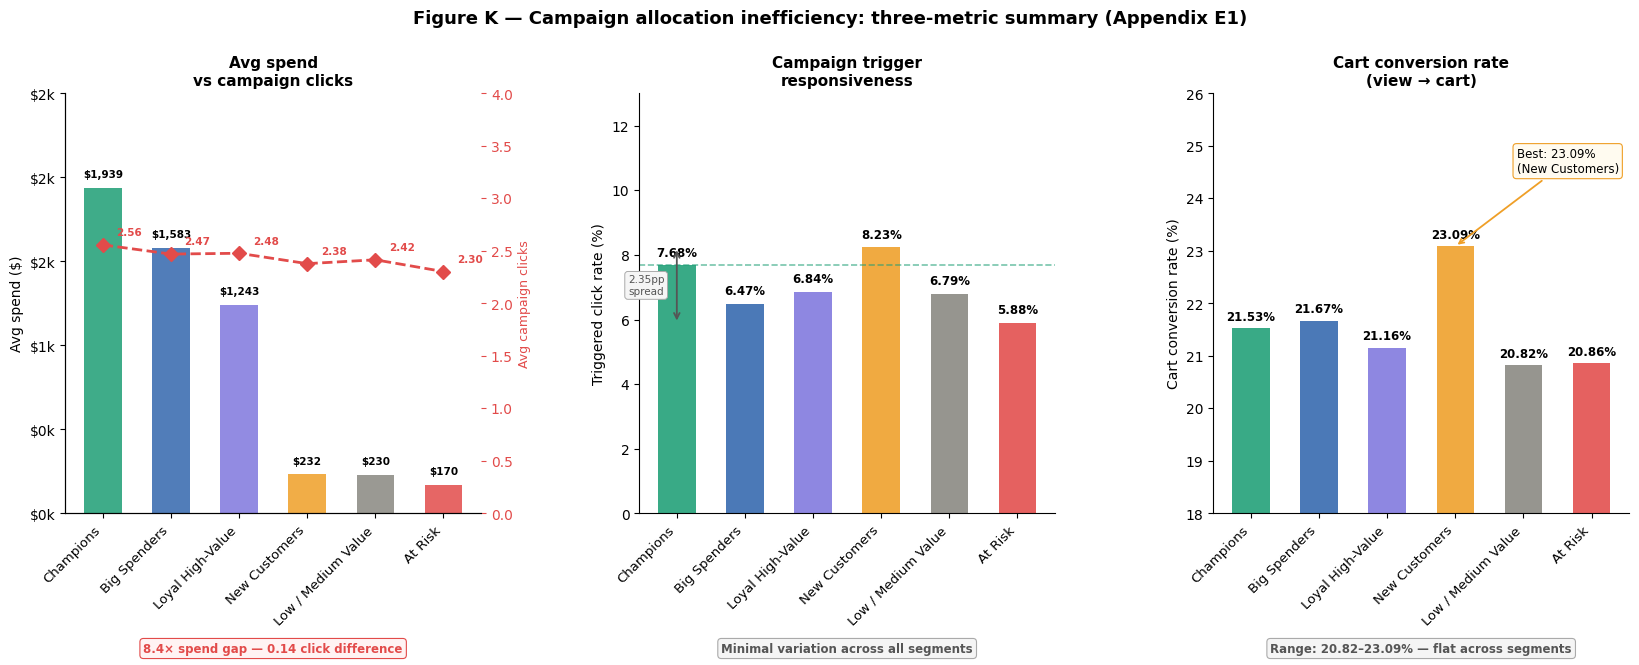

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded ✓


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

r = pd.read_csv('rfm_segments.csv')

SEG_ORDER = ['Champions','Big Spenders','Loyal High-Value',
             'New Customers','Low / Medium Value','At Risk']
SEG_COLORS = {
    'Champions': '#1D9E75', 'Big Spenders': '#3266AD',
    'Loyal High-Value': '#7F77DD', 'New Customers': '#EF9F27',
    'Low / Medium Value': '#888780', 'At Risk': '#E24B4A',
}

agg = (r.groupby('rfm_segment')
    .agg(avg_spend=('total_spend','mean'),
         avg_camp_clicks=('campaign_clicks','mean'),
         avg_triggered=('triggered_clicks','mean'),
         avg_view=('view_clicks','mean'),
         avg_cart=('cart_clicks','mean'))
    .reset_index())
agg['triggered_pct'] = agg['avg_triggered'] / agg['avg_camp_clicks'] * 100
agg['cart_rate']     = agg['avg_cart'] / agg['avg_view'] * 100
agg = agg.set_index('rfm_segment').loc[SEG_ORDER].reset_index()

segs       = agg['rfm_segment'].tolist()
spends     = agg['avg_spend'].tolist()
clicks     = agg['avg_camp_clicks'].tolist()
trig_pcts  = agg['triggered_pct'].tolist()
cart_rates = agg['cart_rate'].tolist()
colors     = [SEG_COLORS[s] for s in segs]
x          = np.arange(len(segs))

# ── Figure K: Three-panel summary ────────────────────────────────────────────
fig = plt.figure(figsize=(17, 6))
fig.suptitle('Figure K — Campaign allocation inefficiency: three-metric summary (Appendix E1)',
             fontsize=13, fontweight='bold', y=1.02)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38,
                       left=0.05, right=0.97, top=0.88, bottom=0.18)

# Panel 1: spend vs clicks
ax1   = fig.add_subplot(gs[0])
ax1_r = ax1.twinx()
ax1.bar(x, spends, color=colors, alpha=0.85, width=0.55)
ax1.set_xticks(x)
ax1.set_xticklabels([s.replace(' /','\n/') for s in segs], fontsize=8.5, ha='center')
ax1.set_ylabel('Avg spend ($)', fontsize=10)
ax1.set_title('Avg spend\nvs campaign clicks', fontsize=11, fontweight='bold', pad=6)
ax1.set_ylim(0, 2500)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
ax1.spines['top'].set_visible(False)
ax1_r.plot(x, clicks, color='#E24B4A', marker='D', ms=7, lw=2, linestyle='--')
ax1_r.set_ylabel('Avg campaign clicks', fontsize=9, color='#E24B4A')
ax1_r.set_ylim(0, 4)
ax1_r.tick_params(axis='y', colors='#E24B4A')
ax1_r.spines['top'].set_visible(False)
for xi, (sp, cl) in enumerate(zip(spends, clicks)):
    ax1.text(xi, sp+50, f'${sp:,.0f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax1_r.text(xi+0.2, cl+0.07, f'{cl:.2f}', ha='left', va='bottom',
               fontsize=7.5, color='#E24B4A', fontweight='bold')
ax1.text(0.5, -0.33, '8.4× spend gap — 0.14 click difference',
    transform=ax1.transAxes, ha='center', fontsize=8.5, color='#E24B4A', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff3f3', ec='#E24B4A', lw=0.8))
ax1.set_xticklabels(segs, fontsize=9.5, rotation=45, ha='right')
ax1.tick_params(axis='x', pad=4)

# Panel 2: triggered %
ax2 = fig.add_subplot(gs[1])
b2 = ax2.bar(x, trig_pcts, color=colors, width=0.55, alpha=0.88)
ax2.set_xticks(x)
ax2.set_xticklabels([s.replace(' /','\n/') for s in segs], fontsize=8.5, ha='center')
ax2.set_ylabel('Triggered click rate (%)', fontsize=10)
ax2.set_title('Campaign trigger\nresponsiveness', fontsize=11, fontweight='bold', pad=6)
ax2.set_ylim(0, 13)
for bar, val in zip(b2, trig_pcts):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax2.axhline(y=trig_pcts[0], color='#1D9E75', lw=1.2, linestyle='--', alpha=0.6)
ax2.annotate('', xy=(0, min(trig_pcts)), xytext=(0, max(trig_pcts)),
    arrowprops=dict(arrowstyle='<->', color='#555', lw=1.3))
ax2.text(-0.45, (min(trig_pcts)+max(trig_pcts))/2,
    f'{max(trig_pcts)-min(trig_pcts):.2f}pp\nspread',
    ha='center', va='center', fontsize=7.5, color='#555',
    bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='#aaa', lw=0.7))
ax2.text(0.5, -0.33, 'Minimal variation across all segments',
    transform=ax2.transAxes, ha='center', fontsize=8.5, color='#555', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='#aaa', lw=0.8))
ax2.set_xticklabels(segs, fontsize=9.5, rotation=45, ha='right')
ax2.tick_params(axis='x', pad=4)

# Panel 3: cart rate
ax3 = fig.add_subplot(gs[2])
b3 = ax3.bar(x, cart_rates, color=colors, width=0.55, alpha=0.88)
ax3.set_xticks(x)
ax3.set_xticklabels([s.replace(' /','\n/') for s in segs], fontsize=8.5, ha='center')
ax3.set_ylabel('Cart conversion rate (%)', fontsize=10)
ax3.set_title('Cart conversion rate\n(view → cart)', fontsize=11, fontweight='bold', pad=6)
ax3.set_ylim(18, 26)
for bar, val in zip(b3, cart_rates):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
new_i = segs.index('New Customers')
ax3.annotate(f'Best: {cart_rates[new_i]:.2f}%\n(New Customers)',
    xy=(new_i, cart_rates[new_i]), xytext=(new_i+0.9, 24.5),
    arrowprops=dict(arrowstyle='->', color='#EF9F27', lw=1.3),
    fontsize=8.5, bbox=dict(boxstyle='round,pad=0.3', fc='#FFFBF0', ec='#EF9F27', lw=0.8))
ax3.text(0.5, -0.33,
    f'Range: {min(cart_rates):.2f}–{max(cart_rates):.2f}% — flat across segments',
    transform=ax3.transAxes, ha='center', fontsize=8.5, color='#555', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='#aaa', lw=0.8))

ax3.set_xticklabels(segs, fontsize=9.5, rotation=45, ha='right')
ax3.tick_params(axis='x', pad=4)

plt.savefig('figK_campaign_inefficiency_summary.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

from google.colab import files
files.download('figK_campaign_inefficiency_summary.png')
print("Downloaded ✓")

/tmp/ipykernel_1337/1375542550.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  d6['positive_pct'] = merged.groupby('rfm_segment').apply(
/tmp/ipykernel_1337/1375542550.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  d7['positive_pct'] = champ.groupby('category').apply(


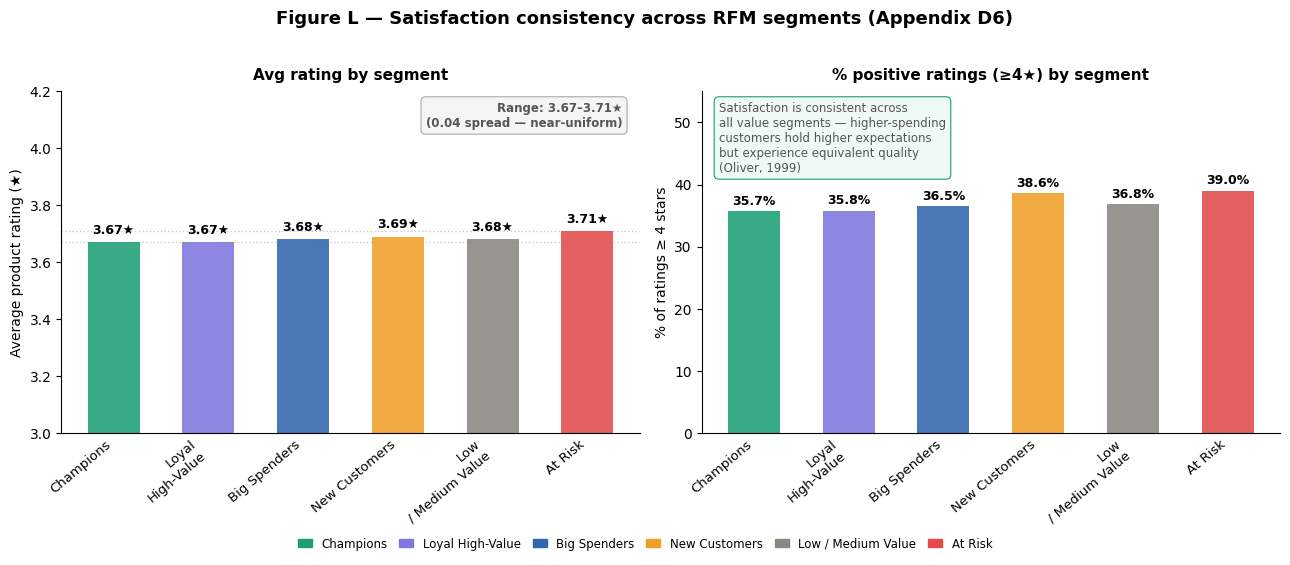

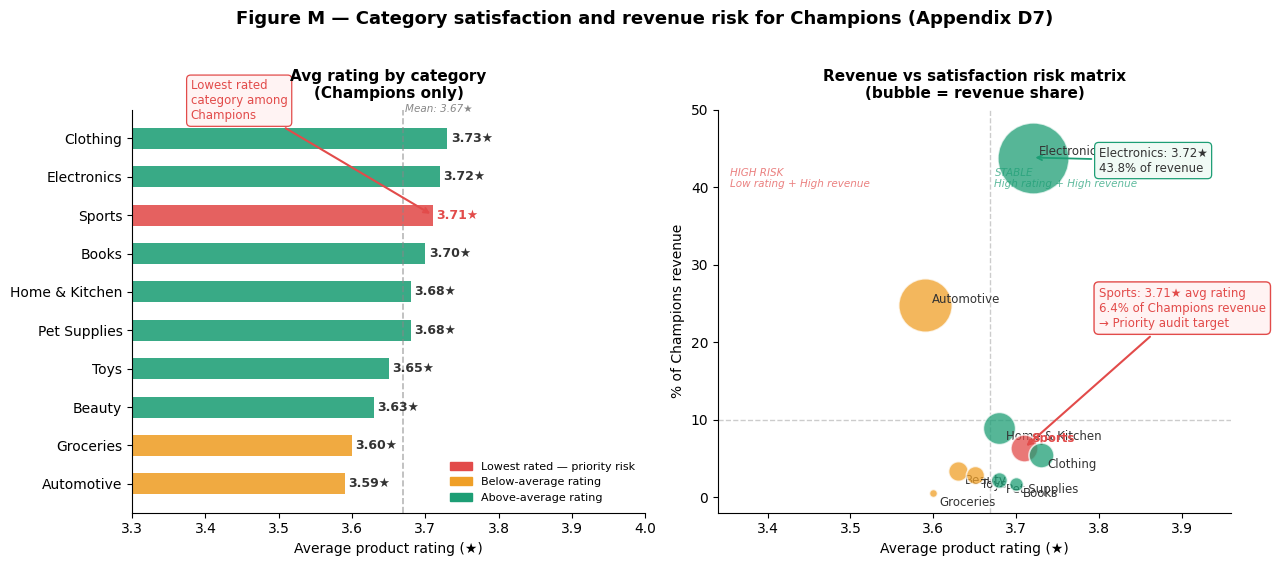

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figL_d6_rating_segments.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figM_d7_category_satisfaction.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

t = pd.read_csv('transactions_cleaned.csv')
r = pd.read_csv('rfm_segments.csv')

t_clean = t[t['order_status'].str.lower().isin(['completed','shipped'])].copy()
merged  = t_clean.merge(r[['user_id','rfm_segment']], on='user_id', how='inner')

SEG_ORDER = ['Champions','Loyal High-Value','Big Spenders',
             'New Customers','Low / Medium Value','At Risk']
SEG_COLORS = {
    'Champions': '#1D9E75', 'Loyal High-Value': '#7F77DD',
    'Big Spenders': '#3266AD', 'New Customers': '#EF9F27',
    'Low / Medium Value': '#888780', 'At Risk': '#E24B4A',
}

# D6
d6 = (merged.groupby('rfm_segment')
    .agg(reviews=('rating','count'), avg_rating=('rating','mean'))
    .reset_index())
d6['positive_pct'] = merged.groupby('rfm_segment').apply(
    lambda x: (x['rating']>=4).sum()/len(x)*100).values
d6 = d6.round(2).set_index('rfm_segment').loc[SEG_ORDER].reset_index()

# D7
champ = merged[merged['rfm_segment'] == 'Champions']
d7 = (champ.groupby('category')
    .agg(reviews=('rating','count'),
         avg_rating=('rating','mean'),
         revenue=('item_total','sum'))
    .reset_index())
d7['positive_pct'] = champ.groupby('category').apply(
    lambda x: (x['rating']>=4).sum()/len(x)*100).values
d7['pct_revenue'] = d7['revenue'] / d7['revenue'].sum() * 100
d7 = d7.round(2).sort_values('avg_rating')

colors_seg = [SEG_COLORS[s] for s in d6['rfm_segment']]
x = np.arange(len(d6))

# ── Figure L: D6 ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
fig.suptitle('Figure L — Satisfaction consistency across RFM segments (Appendix D6)',
             fontsize=13, fontweight='bold', y=1.02)

ax = axes[0]
bars = ax.bar(x, d6['avg_rating'], color=colors_seg, width=0.55, alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(
    [s.replace(' /','\n/').replace('Loyal ','Loyal\n') for s in d6['rfm_segment']],
    fontsize=9.5, rotation=40, ha='right')
ax.tick_params(axis='x', pad=3, length=0)
ax.set_ylabel('Average product rating (★)', fontsize=10)
ax.set_title('Avg rating by segment', fontsize=11, fontweight='bold', pad=8)
ax.set_ylim(3.0, 4.2)
for bar, val in zip(bars, d6['avg_rating']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.2f}★', ha='center', va='bottom', fontsize=9, fontweight='bold')
spread = d6['avg_rating'].max() - d6['avg_rating'].min()
ax.axhline(y=d6['avg_rating'].min(), color='#ccc', lw=1, linestyle=':', zorder=0)
ax.axhline(y=d6['avg_rating'].max(), color='#ccc', lw=1, linestyle=':', zorder=0)
ax.text(0.97, 0.97,
    f'Range: {d6["avg_rating"].min():.2f}–{d6["avg_rating"].max():.2f}★\n'
    f'({spread:.2f} spread — near-uniform)',
    transform=ax.transAxes, fontsize=8.5, va='top', ha='right', color='#555',
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', fc='#f5f5f5', ec='#aaa', lw=0.8))

ax2 = axes[1]
bars2 = ax2.bar(x, d6['positive_pct'], color=colors_seg, width=0.55, alpha=0.88)
ax2.set_xticks(x)
ax2.set_xticklabels(
    [s.replace(' /','\n/').replace('Loyal ','Loyal\n') for s in d6['rfm_segment']],
    fontsize=9.5, rotation=40, ha='right')
ax2.tick_params(axis='x', pad=3, length=0)
ax2.set_ylabel('% of ratings ≥ 4 stars', fontsize=10)
ax2.set_title('% positive ratings (≥4★) by segment', fontsize=11, fontweight='bold', pad=8)
ax2.set_ylim(0, 55)
for bar, val in zip(bars2, d6['positive_pct']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.text(0.03, 0.97,
    'Satisfaction is consistent across\nall value segments — higher-spending\ncustomers hold higher expectations\nbut experience equivalent quality\n(Oliver, 1999)',
    transform=ax2.transAxes, fontsize=8.5, va='top', ha='left', color='#555',
    bbox=dict(boxstyle='round,pad=0.4', fc='#f0faf5', ec='#1D9E75', lw=0.8))

fig.legend(
    handles=[mpatches.Patch(color=SEG_COLORS[s], label=s) for s in SEG_ORDER],
    fontsize=8.5, loc='lower center', bbox_to_anchor=(0.5,-0.04),
    ncol=6, frameon=False, handlelength=1.2, columnspacing=1.0)
plt.tight_layout()
plt.savefig('figL_d6_rating_segments.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Figure M: D7 ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Figure M — Category satisfaction and revenue risk for Champions (Appendix D7)',
             fontsize=13, fontweight='bold', y=1.02)

cat_colors = ['#E24B4A' if c=='Sports'
              else '#EF9F27' if c in ['Automotive','Groceries']
              else '#1D9E75' for c in d7['category']]

ax = axes[0]
bars = ax.barh(d7['category'], d7['avg_rating'],
               color=cat_colors, height=0.55, alpha=0.88)
ax.set_xlabel('Average product rating (★)', fontsize=10)
ax.set_title('Avg rating by category\n(Champions only)', fontsize=11,
             fontweight='bold', pad=8)
ax.set_xlim(3.3, 4.0)
for bar, val, cat in zip(bars, d7['avg_rating'], d7['category']):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}★', va='center', fontsize=9, fontweight='bold',
            color='#E24B4A' if cat=='Sports' else '#333')
sports_idx = d7['category'].tolist().index('Sports')
ax.annotate('Lowest rated\ncategory among\nChampions',
    xy=(d7.loc[d7['category']=='Sports','avg_rating'].values[0], sports_idx),
    xytext=(3.38, sports_idx+2.5),
    arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1.5),
    fontsize=8.5, color='#E24B4A',
    bbox=dict(boxstyle='round,pad=0.35', fc='#FFF3F3', ec='#E24B4A', lw=0.9))
ax.axvline(x=d7['avg_rating'].mean(), color='#888', lw=1.2, linestyle='--', alpha=0.6)
ax.text(d7['avg_rating'].mean()+0.003, len(d7)-0.3,
        f'Mean: {d7["avg_rating"].mean():.2f}★', fontsize=7.5, color='#888', style='italic')
ax.legend(handles=[
    mpatches.Patch(color='#E24B4A', label='Lowest rated — priority risk'),
    mpatches.Patch(color='#EF9F27', label='Below-average rating'),
    mpatches.Patch(color='#1D9E75', label='Above-average rating'),
], fontsize=8, loc='lower right', frameon=False)

ax2 = axes[1]
for _, row in d7.iterrows():
    cat    = row['category']
    rating = row['avg_rating']
    rev    = row['pct_revenue']
    color  = '#E24B4A' if cat=='Sports' \
             else '#EF9F27' if rating < d7['avg_rating'].mean() \
             else '#1D9E75'
    ax2.scatter(rating, rev, s=rev*60, color=color,
                alpha=0.75, edgecolors='white', linewidth=1.2, zorder=3)
    offset_y = 1.2 if cat=='Sports' else (0.8 if rev>15 else -1.2)
    ax2.text(rating+0.008, rev+offset_y, cat, fontsize=8.5, va='center', ha='left',
             color='#E24B4A' if cat=='Sports' else '#333',
             fontweight='bold' if cat=='Sports' else 'normal')

mean_rating = d7['avg_rating'].mean()
mean_rev    = d7['pct_revenue'].mean()
ax2.axvline(x=mean_rating, color='#ccc', lw=1, linestyle='--', zorder=0)
ax2.axhline(y=mean_rev,    color='#ccc', lw=1, linestyle='--', zorder=0)
ax2.text(3.355, d7['pct_revenue'].max()*0.97,
         'HIGH RISK\nLow rating + High revenue',
         fontsize=7.5, color='#E24B4A', va='top', style='italic', alpha=0.7)
ax2.text(mean_rating+0.005, d7['pct_revenue'].max()*0.97,
         'STABLE\nHigh rating + High revenue',
         fontsize=7.5, color='#1D9E75', va='top', style='italic', alpha=0.7)
ax2.set_xlabel('Average product rating (★)', fontsize=10)
ax2.set_ylabel('% of Champions revenue', fontsize=10)
ax2.set_title('Revenue vs satisfaction risk matrix\n(bubble = revenue share)',
              fontsize=11, fontweight='bold', pad=8)
ax2.set_xlim(3.34, 3.96)
ax2.set_ylim(-2, 50)

sports_row = d7[d7['category']=='Sports'].iloc[0]
ax2.annotate(
    f'Sports: {sports_row["avg_rating"]:.2f}★ avg rating\n'
    f'{sports_row["pct_revenue"]:.1f}% of Champions revenue\n→ Priority audit target',
    xy=(sports_row['avg_rating'], sports_row['pct_revenue']),
    xytext=(3.80, 22),
    arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1.5),
    fontsize=8.5, color='#E24B4A',
    bbox=dict(boxstyle='round,pad=0.4', fc='#FFF3F3', ec='#E24B4A', lw=1.0))

elec_row = d7[d7['category']=='Electronics'].iloc[0]
ax2.annotate(
    f'Electronics: {elec_row["avg_rating"]:.2f}★\n{elec_row["pct_revenue"]:.1f}% of revenue',
    xy=(elec_row['avg_rating'], elec_row['pct_revenue']),
    xytext=(3.80, 42),
    arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=1.3),
    fontsize=8.5, color='#333',
    bbox=dict(boxstyle='round,pad=0.35', fc='#f0faf5', ec='#1D9E75', lw=0.9))

plt.tight_layout()
plt.savefig('figM_d7_category_satisfaction.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

from google.colab import files
for f in ['figL_d6_rating_segments.png','figM_d7_category_satisfaction.png']:
    files.download(f)
    print(f"Downloaded: {f}")

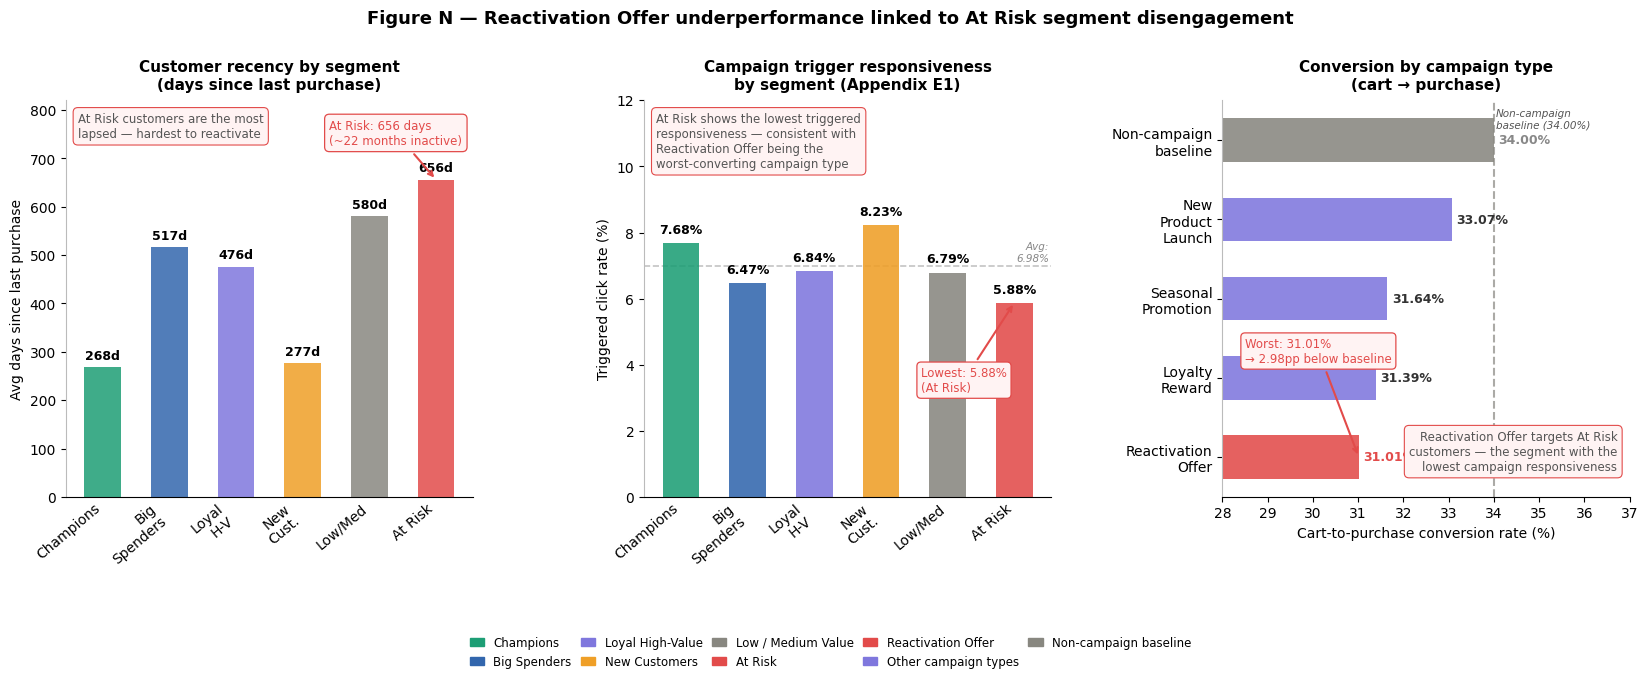

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded ✓


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

r = pd.read_csv('rfm_segments.csv')
f = pd.read_csv('funnel_table.csv')
c = pd.read_csv('campaign_table.csv')

SEG_ORDER = ['Champions','Big Spenders','Loyal High-Value',
             'New Customers','Low / Medium Value','At Risk']
SEG_COLORS = {
    'Champions': '#1D9E75', 'Big Spenders': '#3266AD',
    'Loyal High-Value': '#7F77DD', 'New Customers': '#EF9F27',
    'Low / Medium Value': '#888780', 'At Risk': '#E24B4A',
}

# Derive E1 metrics live
agg = (r.groupby('rfm_segment')
    .agg(avg_recency=('recency_days','mean'),
         avg_camp_clicks=('campaign_clicks','mean'),
         avg_triggered=('triggered_clicks','mean'),
         avg_view=('view_clicks','mean'),
         avg_cart=('cart_clicks','mean'),
         avg_spend=('total_spend','mean'))
    .reset_index())
agg['triggered_pct'] = agg['avg_triggered'] / agg['avg_camp_clicks'] * 100
agg['cart_rate']     = agg['avg_cart'] / agg['avg_view'] * 100
agg = agg.set_index('rfm_segment').loc[SEG_ORDER].reset_index()

# Derive campaign type conversion
active = c[c['campaign_active'] == 1]
ct = (active.groupby('campaign_type')
    .agg(total_clicks=('total_clicks','sum'),
         views=('views','sum'),
         carts=('carts','sum'),
         purchases=('purchase_clicks','sum'),
         triggered=('triggered_clicks','sum'))
    .reset_index())
ct['c2p'] = ct['purchases'] / ct['carts'] * 100
ct = ct.sort_values('c2p')

# Add non-campaign baseline
non_c2p = f[f['campaign_active']==0].agg(
    {'carts':'sum','purchase_clicks':'sum'})
baseline = non_c2p['purchase_clicks'] / non_c2p['carts'] * 100

segs       = agg['rfm_segment'].tolist()
recencies  = agg['avg_recency'].tolist()
trig_segs  = agg['triggered_pct'].tolist()
seg_colors = [SEG_COLORS[s] for s in segs]
x_seg      = np.arange(len(segs))
at_i       = segs.index('At Risk')

camp_labels = ct['campaign_type'].str.replace('_','\n').tolist() + ['Non-campaign\nbaseline']
c2p_vals    = ct['c2p'].tolist() + [baseline]
camp_colors = ['#E24B4A' if 'Reactivation' in l
               else '#888780' if 'Non-campaign' in l
               else '#7F77DD'
               for l in camp_labels]

SHORT = {
    'Champions': 'Champions', 'Big Spenders': 'Big\nSpenders',
    'Loyal High-Value': 'Loyal\nH-V', 'New Customers': 'New\nCust.',
    'Low / Medium Value': 'Low/Med', 'At Risk': 'At Risk',
}
xlabels_seg = [SHORT[s] for s in segs]

fig = plt.figure(figsize=(17, 6.5))
fig.suptitle(
    'Figure N — Reactivation Offer underperformance linked to At Risk segment disengagement',
    fontsize=13, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42,
                       left=0.05, right=0.97, top=0.87, bottom=0.26)

# Panel 1: recency
ax1 = fig.add_subplot(gs[0])
bars1 = ax1.bar(x_seg, recencies, color=seg_colors, width=0.55, alpha=0.85)
ax1.set_xticks(x_seg)
ax1.set_xticklabels(xlabels_seg, fontsize=10, rotation=40, ha='right')
ax1.tick_params(axis='x', pad=3, length=0)
ax1.set_ylabel('Avg days since last purchase', fontsize=10)
ax1.set_title('Customer recency by segment\n(days since last purchase)',
              fontsize=11, fontweight='bold', pad=8)
ax1.set_ylim(0, 820)
ax1.spines['left'].set_color('#bbb')
for bar, val in zip(bars1, recencies):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
             f'{val:.0f}d', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.annotate(f'At Risk: {recencies[at_i]:.0f} days\n(~22 months inactive)',
    xy=(at_i, recencies[at_i]), xytext=(at_i-1.6, 730),
    arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1.5),
    fontsize=8.5, color='#E24B4A',
    bbox=dict(boxstyle='round,pad=0.4', fc='#FFF3F3', ec='#E24B4A', lw=0.9))
ax1.text(0.03, 0.97,
    'At Risk customers are the most\nlapsed — hardest to reactivate',
    transform=ax1.transAxes, fontsize=8.5, va='top', ha='left', color='#555',
    bbox=dict(boxstyle='round,pad=0.4', fc='#FFF3F3', ec='#E24B4A', lw=0.8))

# Panel 2: triggered %
ax2 = fig.add_subplot(gs[1])
bars2 = ax2.bar(x_seg, trig_segs, color=seg_colors, width=0.55, alpha=0.88)
ax2.set_xticks(x_seg)
ax2.set_xticklabels(xlabels_seg, fontsize=10, rotation=40, ha='right')
ax2.tick_params(axis='x', pad=3, length=0)
ax2.set_ylabel('Triggered click rate (%)', fontsize=10)
ax2.set_title('Campaign trigger responsiveness\nby segment (Appendix E1)',
              fontsize=11, fontweight='bold', pad=8)
ax2.set_ylim(0, 12)
ax2.spines['left'].set_color('#bbb')
for bar, val in zip(bars2, trig_segs):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.annotate(f'Lowest: {trig_segs[at_i]:.2f}%\n(At Risk)',
    xy=(at_i, trig_segs[at_i]), xytext=(at_i-1.4, 3.2),
    arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1.5),
    fontsize=8.5, color='#E24B4A',
    bbox=dict(boxstyle='round,pad=0.35', fc='#FFF3F3', ec='#E24B4A', lw=0.9))
ax2.text(0.03, 0.97,
    'At Risk shows the lowest triggered\nresponsiveness — consistent with\nReactivation Offer being the\nworst-converting campaign type',
    transform=ax2.transAxes, fontsize=8.5, va='top', ha='left', color='#555',
    bbox=dict(boxstyle='round,pad=0.4', fc='#FFF3F3', ec='#E24B4A', lw=0.8))
avg_trig = np.mean(trig_segs)
ax2.axhline(y=avg_trig, color='#888', lw=1.2, linestyle='--', alpha=0.5, zorder=0)
ax2.text(5.52, avg_trig+0.15, f'Avg:\n{avg_trig:.2f}%',
         ha='right', fontsize=7.5, color='#888', style='italic')

# Panel 3: campaign type c2p
ax3 = fig.add_subplot(gs[2])
bars3 = ax3.barh(camp_labels, c2p_vals, color=camp_colors, height=0.55, alpha=0.88)
ax3.set_xlabel('Cart-to-purchase conversion rate (%)', fontsize=10)
ax3.set_title('Conversion by campaign type\n(cart → purchase)',
              fontsize=11, fontweight='bold', pad=8)
ax3.set_xlim(28, 37)
ax3.spines['left'].set_color('#bbb')
for bar, val, label in zip(bars3, c2p_vals, camp_labels):
    color = '#E24B4A' if 'Reactivation' in label \
            else '#888' if 'Non-campaign' in label else '#333'
    ax3.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=9,
             fontweight='bold', color=color)
ax3.axvline(x=baseline, color='#888780', lw=1.5, linestyle='--', alpha=0.7)
ax3.text(baseline+0.05, len(camp_labels)-0.6,
         f'Non-campaign\nbaseline ({baseline:.2f}%)',
         fontsize=7.5, color='#555', style='italic', va='top')
react_idx = next(i for i,l in enumerate(camp_labels) if 'Reactivation' in l)
ax3.annotate(
    f'Worst: {c2p_vals[react_idx]:.2f}%\n→ {baseline-c2p_vals[react_idx]:.2f}pp below baseline',
    xy=(c2p_vals[react_idx], react_idx),
    xytext=(28.5, react_idx+1.2),
    arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1.5),
    fontsize=8.5, color='#E24B4A',
    bbox=dict(boxstyle='round,pad=0.35', fc='#FFF3F3', ec='#E24B4A', lw=0.9))
ax3.text(0.97, 0.06,
    'Reactivation Offer targets At Risk\ncustomers — the segment with the\nlowest campaign responsiveness',
    transform=ax3.transAxes, fontsize=8.5, va='bottom', ha='right', color='#555',
    bbox=dict(boxstyle='round,pad=0.4', fc='#FFF3F3', ec='#E24B4A', lw=0.8))

fig.legend(
    handles=[mpatches.Patch(color=SEG_COLORS[s], label=s) for s in SEG_ORDER] + [
        mpatches.Patch(color='#E24B4A', label='Reactivation Offer'),
        mpatches.Patch(color='#7F77DD', label='Other campaign types'),
        mpatches.Patch(color='#888780', label='Non-campaign baseline'),
    ],
    fontsize=8.5, loc='lower center', bbox_to_anchor=(0.5,-0.02),
    ncol=5, frameon=False, handlelength=1.2, columnspacing=0.8)

plt.savefig('figN_reactivation_risk.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

from google.colab import files
files.download('figN_reactivation_risk.png')
print("Downloaded ✓")